In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:

node_indices = np.array(range(30))

# -----------------------------
# Node features
# [1] = traversable
# [0] = blocked / not allowed
# -----------------------------
non_traversable_nodes = {4, 9, 17, 23, 27}

node_features = [
    [0 if i in non_traversable_nodes else 1]
    for i in range(30)
]

# -----------------------------
# Original edge list
# -----------------------------
edges = [
    # Main backbone
    (0, 1), (1, 2), (2, 3), (3, 4), (4, 5),
    (5, 6), (6, 7), (7, 8), (8, 9), (9, 10),
    (10, 11), (11, 12), (12, 13), (13, 14),

    # Branches
    (2, 15), (15, 16),
    (4, 17),
    (6, 18), (18, 19),
    (8, 20),
    (10, 21), (21, 22),
    (12, 23),
    (14, 24), (24, 25),

    # Cycles / cross-links
    (3, 6),
    (7, 10),
    (9, 12),
    (16, 18),
    (19, 21),

    # Tail
    (25, 26), (26, 27), (27, 28),
    (27, 29)
]




In [3]:
## Writing the code for the graph search

def evaluate_neighbor_node(curr_node_id, node_id1, node_id2, node_path):
    '''
    Helper function that identifies whether the node
    will be added as a neighbor based on whether it
    is already in the node path
    '''

    if curr_node_id == node_id1 and node_id2 not in node_path:
        return node_id2
    elif curr_node_id == node_id2 and node_id1 not in node_path:
        return node_id1
        
    return -100 ## no node should be added to the neighbor list

def longest_continuous_path_graph(node_indices, node_features, edges, pos_id = 0):
    '''
    Finds the longest continuous path along a non-directional graph
    that can have any level of connectivity. Also reports the number of branches
    along that path

    node_indices: numpy array length N
    node_features: numpy array length Nxf where f is the number of features
    edges: numpy array of length Ex2, where E is the number of edges in the graph (i,j) between nodes i and j
    '''

    search_queue = [] ## queue with each path inside of it - [([path_list], path, length, complete_path_bit)...]
    finished_paths = [] ## Where the completed paths are sent after they are done with the search queue

    ## add first node to the queue with simple search

    for i in range(len(node_indices)):
        if node_features[i][pos_id] == 1:
            ## positive found - add to queue

            search_queue.append(([i], 1, 0)) 
            

    max_iter = 10000000
    my_iter = 0
    while len(search_queue) > 0:

        ## Failsafe during testing
        my_iter +=1
        if my_iter > max_iter:
            print("FAILSAFE ACTIVATED")
            break

        ## Get the current node from the queue
        
        curr_node = search_queue.pop()

        node_path, node_len, complete_bit = curr_node

        curr_node_id = node_path[-1] ## most recent node index in the path

        ## Get all neighbors of the current node that aren't already in the current path (to prevent back tracking)

        temp_neighbor_ids = []
        for edge in edges:
            if curr_node_id in edge:
                neighbor_id = evaluate_neighbor_node(curr_node_id, edge[0], edge[1], node_path)

                ## Check to make sure the returned neighbor ID is greater than -1 (should be added)
                ## Only neighbors not in the node_path are added if they have a node feature value of 1
                if neighbor_id > -1 and node_features[neighbor_id][pos_id] == 1:
                    temp_neighbor_ids.append(neighbor_id)

        ## Loop through all neighbors\

        if len(temp_neighbor_ids) < 1:

            complete_bit = 1
            finished_paths.append((node_path, node_len, complete_bit))

        for neighbor_id in temp_neighbor_ids:

            ## All neighbors should be valid and not already in the current path, so add them to the queue

            tmp_node_path = node_path + [neighbor_id]
            tmp_node_len = node_len + 1
            complete_bit = 0
            search_queue.append((tmp_node_path, tmp_node_len, complete_bit))

    return finished_paths
            

In [4]:
## Test the code

test_paths = longest_continuous_path_graph(node_indices, node_features, edges)

In [5]:
## Find the branches of the longest path

from collections import defaultdict

def build_adj(edges):
    '''
    Builds a quick adjacency matrix of the edges
    '''
    adj = defaultdict(list)
    for u, v in edges:
        adj[u].append(v)
        adj[v].append(u)
    return adj

def path_branchiness(path, adj, node_features, pos_id=0):
    '''
    Calculates the total number of branches along the path
    '''
    branch_points = 0
    total_side_exits = 0

    for i, v in enumerate(path):
        prev_v = path[i-1] if i > 0 else None
        next_v = path[i+1] if i < len(path)-1 else None

        side_exits = 0
        for nb in adj[v]:
            if node_features[nb][pos_id] != 1:
                continue
            if nb == prev_v or nb == next_v:
                continue
            if nb in path:
                continue
            side_exits += 1

        if side_exits > 0:
            branch_points += 1
        total_side_exits += side_exits

    return branch_points, total_side_exits


In [6]:
sorted_paths = sorted(test_paths, key=lambda x: x[1], reverse = True)
for i in range(5):
    print(sorted_paths[i])

([26, 25, 24, 14, 13, 12, 11, 10, 21, 19, 18, 16, 15, 2, 3, 6, 7, 8, 20], 19, 1)
([20, 8, 7, 6, 3, 2, 15, 16, 18, 19, 21, 10, 11, 12, 13, 14, 24, 25, 26], 19, 1)
([26, 25, 24, 14, 13, 12, 11, 10, 7, 6, 3, 2, 15, 16, 18, 19, 21, 22], 18, 1)
([25, 24, 14, 13, 12, 11, 10, 21, 19, 18, 16, 15, 2, 3, 6, 7, 8, 20], 18, 1)
([22, 21, 19, 18, 16, 15, 2, 3, 6, 7, 10, 11, 12, 13, 14, 24, 25, 26], 18, 1)


In [7]:
longest_path = sorted_paths[0][0]
tmp_adj = build_adj(edges)

tmp_branch_points, total_side_exits = path_branchiness(longest_path, tmp_adj, node_features)


In [8]:
print(tmp_branch_points, total_side_exits)

3 3


## Visualizing the graphs with networkX

In [9]:
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt

def build_graph(node_indices, node_features, edges, pos_id=0):
    """
    Build a NetworkX graph. Keeps all nodes, but stores traversability on each node.
    """
    G = nx.Graph()
    for i in node_indices:
        G.add_node(int(i), traversable=int(node_features[i][pos_id]))
    for u, v in edges:
        G.add_edge(int(u), int(v))
    return G

def draw_graph_with_path(G, path=None, seed=7, show_blocked=True, title=None):
    """
    Draw the graph; optionally highlight a path.
    - show_blocked=True: includes blocked nodes (isolated), if present in G
    """
    pos = nx.spring_layout(G, seed=seed)  # stable layout with seed

    traversable_nodes = [n for n, d in G.nodes(data=True) if d.get("traversable", 1) == 1]
    blocked_nodes     = [n for n, d in G.nodes(data=True) if d.get("traversable", 1) == 0]

    plt.figure(figsize=(10, 7), dpi=150)

    # Base edges
    nx.draw_networkx_edges(G, pos, alpha=0.35, width=1.2)

    # Traversable nodes
    nx.draw_networkx_nodes(
        G, pos,
        nodelist=traversable_nodes,
        node_size=420, 
        node_color = "lightblue"
    )

    # Blocked nodes (optional)
    if show_blocked and len(blocked_nodes) > 0:
        nx.draw_networkx_nodes(
            G, pos,
            nodelist=blocked_nodes,
            node_size=420,
            node_shape="X", 
            node_color = "lightcoral"
        )

    # Labels
    nx.draw_networkx_labels(G, pos, font_size=9)

    # Highlight path if provided
    if path is not None and len(path) > 1:
        path_edges = list(zip(path[:-1], path[1:]))

        nx.draw_networkx_edges(
            G, pos,
            edgelist=path_edges,
            width=4.0,
            alpha=0.9
        )
        nx.draw_networkx_nodes(
            G, pos,
            nodelist=path,
            node_size=520
        )

    if title:
        plt.title(title)
    plt.axis("off")
    plt.show()


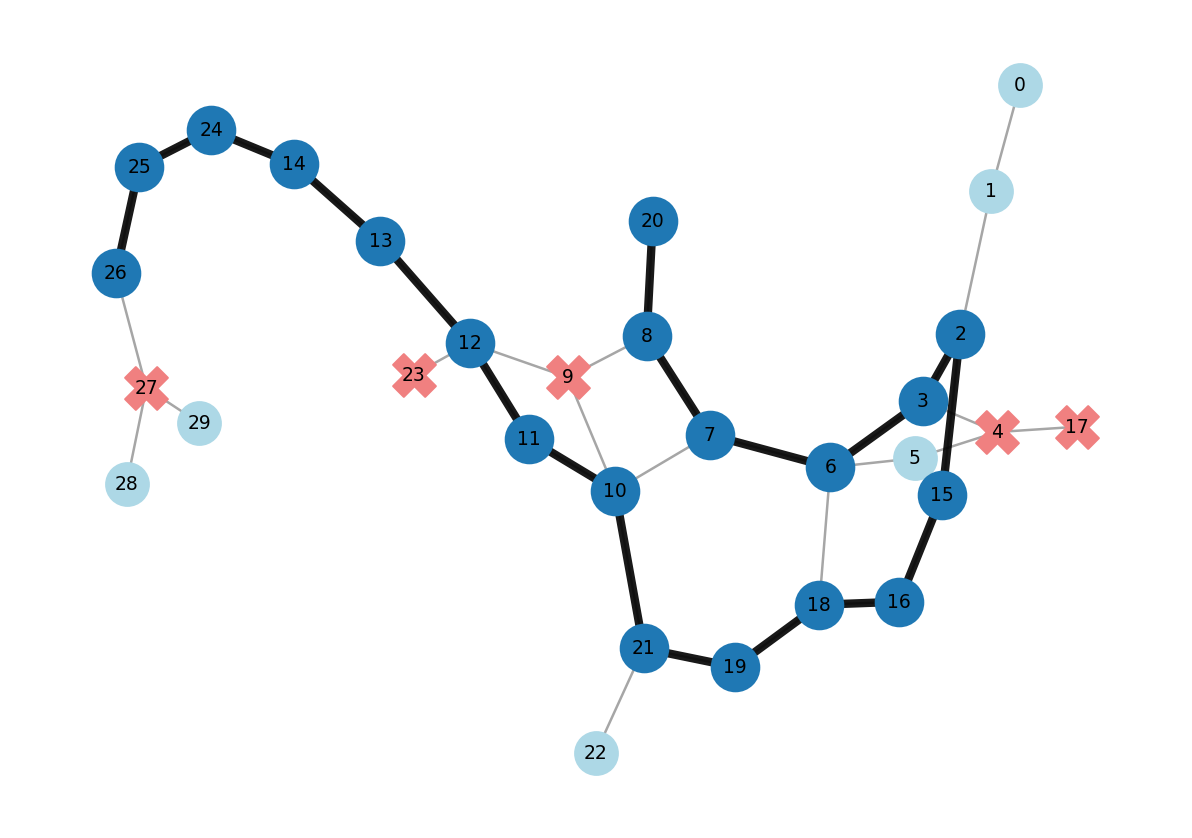

In [10]:
G = build_graph(node_indices, node_features, edges, pos_id=0)

draw_graph_with_path(
    G,
    path=longest_path,
    seed=14,
    show_blocked=True
)

## Harder test

In [42]:

node_indices = np.arange(70)

# -----------------------------
# Node features: [traversable]
# -----------------------------
# Intentionally block a few interior nodes to force detours
non_traversable_nodes = {
    6, 12, 19, 27, 33, 41, 48, 55, 61
}

node_features = [
    [0 if i in non_traversable_nodes else 1]
    for i in range(70)
]

# -----------------------------
# Edge list (undirected)
# Backbone + branches + cycles
# -----------------------------
edges = [
    # Main backbone (long chain)
    (0, 1), (1, 2), (2, 3), (3, 4), (4, 5),
    (5, 6), (6, 7), (7, 8), (8, 9), (9, 10),
    (10, 11), (11, 12), (12, 13), (13, 14),
    (14, 15), (15, 16), (16, 17), (17, 18),
    (18, 19), (19, 20), (20, 21), (21, 22),
    (22, 23), (23, 24), (24, 25), (25, 26),
    (26, 27), (27, 28), (28, 29), (29, 30),
    (30, 31), (31, 32), (32, 33), (33, 34),
    (34, 35), (35, 36), (36, 37), (37, 38),
    (38, 39), (39, 40), (40, 41), (41, 42),
    (42, 43), (43, 44), (44, 45), (45, 46),
    (46, 47), (47, 48), (48, 49), (49, 50),
    (50, 51), (51, 52), (52, 53), (53, 54),
    (54, 55), (55, 56), (56, 57), (57, 58),
    (58, 59), (59, 60), (60, 61), (61, 62),
    (62, 63), (63, 64), (64, 65), (65, 66),
    (66, 67), (67, 68), (68, 69),

    # Branches off the backbone
    (3, 70-1),   # small early branch
    (8, 52),
    (14, 45),
    (21, 38),
    (28, 60),
    (35, 10),
    (42, 25),
    (50, 32),
    (58, 17),

    # Local cycles / cross-links
    (2, 7),
    (4, 9),
    (10, 15),
    (16, 21),
    (22, 27),
    (30, 35),
    (37, 42),
    (44, 49),
    (52, 57),
    (60, 65),

    # Secondary branches
    (9, 18),
    (18, 26),
    (26, 34),
    (34, 43),
    (43, 51),
    (51, 59),
    (59, 67),

    # Deep fork near the end
    (63, 55),
    (63, 56),
]


In [45]:
## Test the code

test_paths = longest_continuous_path_graph(node_indices, node_features, edges)

sorted_paths = sorted(test_paths, key=lambda x: x[1], reverse = True)
for i in range(5):
    print(sorted_paths[i])

longest_path = sorted_paths[0][0]
tmp_adj = build_adj(edges)

tmp_branch_points, total_side_exits = path_branchiness(longest_path, tmp_adj, node_features)

print(tmp_branch_points, total_side_exits)

FAILSAFE ACTIVATED
([69, 68, 67, 66, 65, 64, 63, 56, 57, 58, 17, 18, 26, 34, 43, 42, 25, 24, 23, 22, 21, 16, 15, 14, 45, 44, 49, 50, 32, 31, 30, 29, 28, 60, 59, 51, 52, 8, 7, 2, 3, 4, 9, 10, 35, 36, 37, 38, 39, 40], 50, 1)
([69, 68, 67, 66, 65, 64, 63, 56, 57, 58, 17, 16, 21, 22, 23, 24, 25, 42, 43, 34, 26, 18, 9, 4, 3, 2, 7, 8, 52, 51, 59, 60, 28, 29, 30, 31, 32, 50, 49, 44, 45, 14, 15, 10, 35, 36, 37, 38, 39, 40], 50, 1)
([69, 68, 67, 66, 65, 64, 63, 56, 57, 58, 59, 60, 28, 29, 30, 31, 32, 50, 49, 44, 45, 14, 15, 10, 9, 4, 3, 2, 7, 8, 52, 51, 43, 42, 25, 24, 23, 22, 21, 16, 17, 18, 26, 34, 35, 36, 37, 38, 39, 40], 50, 1)
([69, 68, 67, 66, 65, 64, 63, 56, 57, 58, 59, 60, 28, 29, 30, 31, 32, 50, 49, 44, 45, 14, 15, 16, 17, 18, 26, 34, 43, 51, 52, 8, 7, 2, 3, 4, 9, 10, 35, 36, 37, 42, 25, 24, 23, 22, 21, 38, 39, 40], 50, 1)
([66, 67, 68, 69, 3, 4, 9, 10, 35, 36, 37, 38, 21, 22, 23, 24, 25, 42, 43, 34, 26, 18, 17, 16, 15, 14, 45, 44, 49, 50, 32, 31, 30, 29, 28, 60, 65, 64, 63, 56, 57, 58

In [15]:
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt

def build_graph(node_indices, node_features, edges, pos_id=0):
    """
    Build a NetworkX graph. Keeps all nodes, but stores traversability on each node.
    """
    G = nx.Graph()
    for i in node_indices:
        G.add_node(int(i), traversable=int(node_features[i][pos_id]))
    for u, v in edges:
        G.add_edge(int(u), int(v))
    return G

def draw_graph_with_path(G, path=None, seed=7, show_blocked=True, title=None):
    """
    Draw the graph; optionally highlight a path.
    - show_blocked=True: includes blocked nodes (isolated), if present in G
    """
    pos = nx.spring_layout(G, seed=seed)  # stable layout with seed

    traversable_nodes = [n for n, d in G.nodes(data=True) if d.get("traversable", 1) == 1]
    blocked_nodes     = [n for n, d in G.nodes(data=True) if d.get("traversable", 1) == 0]

    plt.figure(figsize=(15, 15), dpi=150)

    # Base edges
    nx.draw_networkx_edges(G, pos, alpha=0.35, width=1.2)

    # Traversable nodes
    nx.draw_networkx_nodes(
        G, pos,
        nodelist=traversable_nodes,
        node_size=420, 
        node_color = "lightblue"
    )

    # Blocked nodes (optional)
    if show_blocked and len(blocked_nodes) > 0:
        nx.draw_networkx_nodes(
            G, pos,
            nodelist=blocked_nodes,
            node_size=420,
            node_shape="X", 
            node_color = "lightcoral"
        )

    # Labels
    nx.draw_networkx_labels(G, pos, font_size=9)

    # Highlight path if provided
    if path is not None and len(path) > 1:
        path_edges = list(zip(path[:-1], path[1:]))

        nx.draw_networkx_edges(
            G, pos,
            edgelist=path_edges,
            width=4.0,
            alpha=0.9
        )
        nx.draw_networkx_nodes(
            G, pos,
            nodelist=path,
            node_size=520
        )

    if title:
        plt.title(title)
    plt.axis("off")
    plt.show()


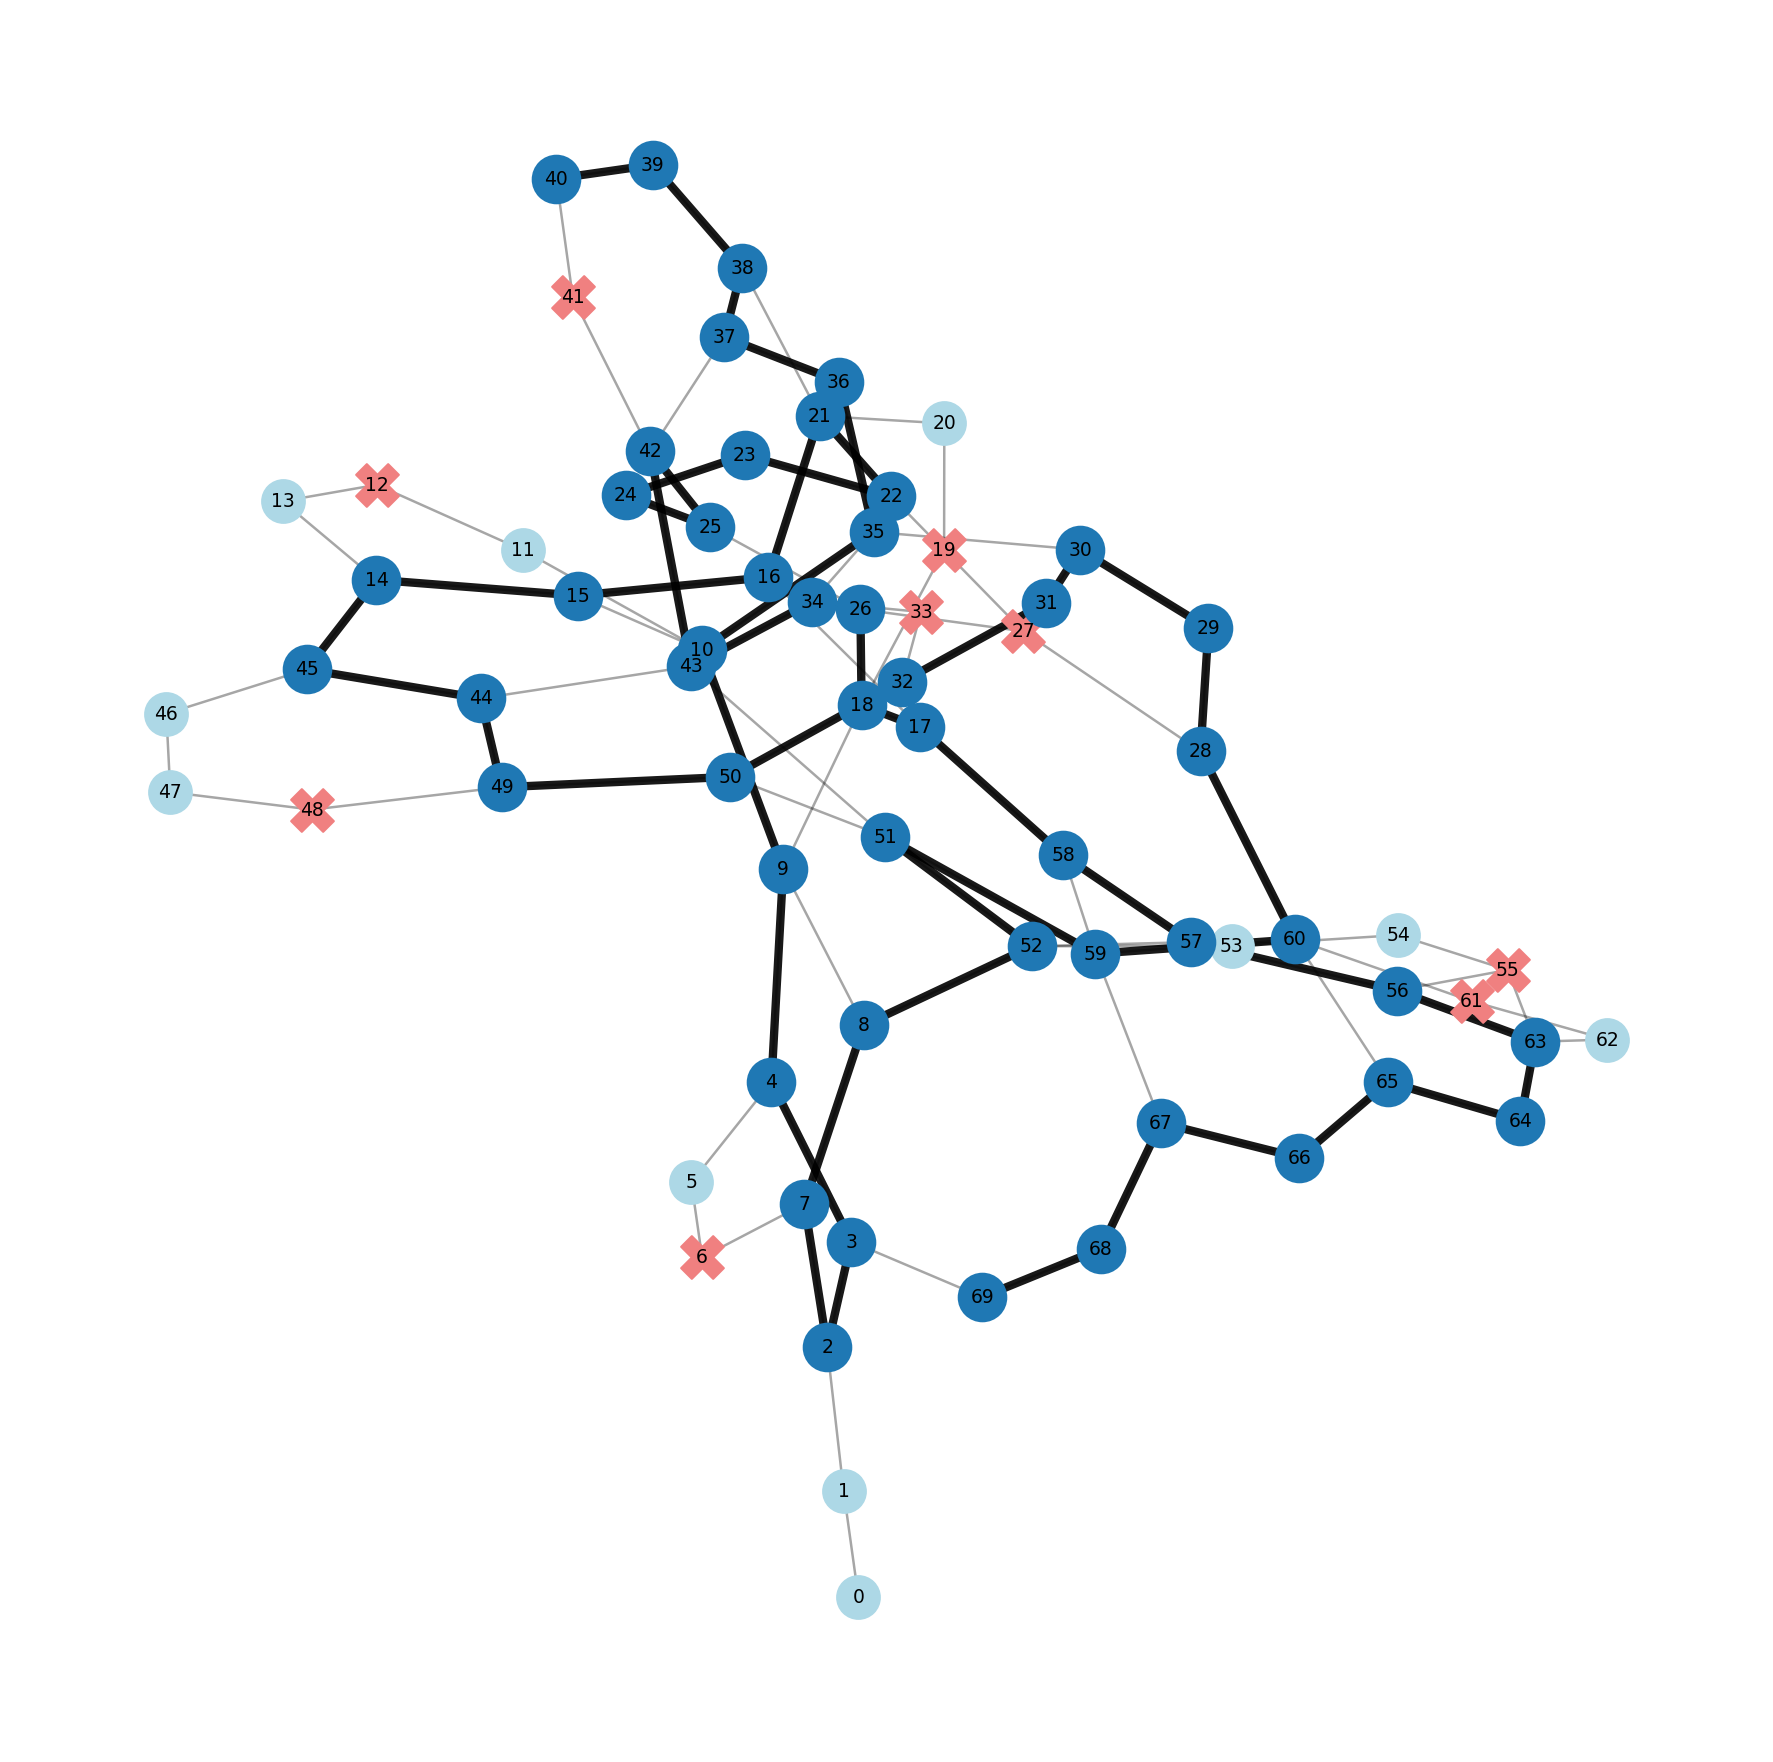

In [56]:
G = build_graph(node_indices, node_features, edges, pos_id=0)

draw_graph_with_path(
    G,
    path=longest_path,
    seed=25,
    show_blocked=True
)

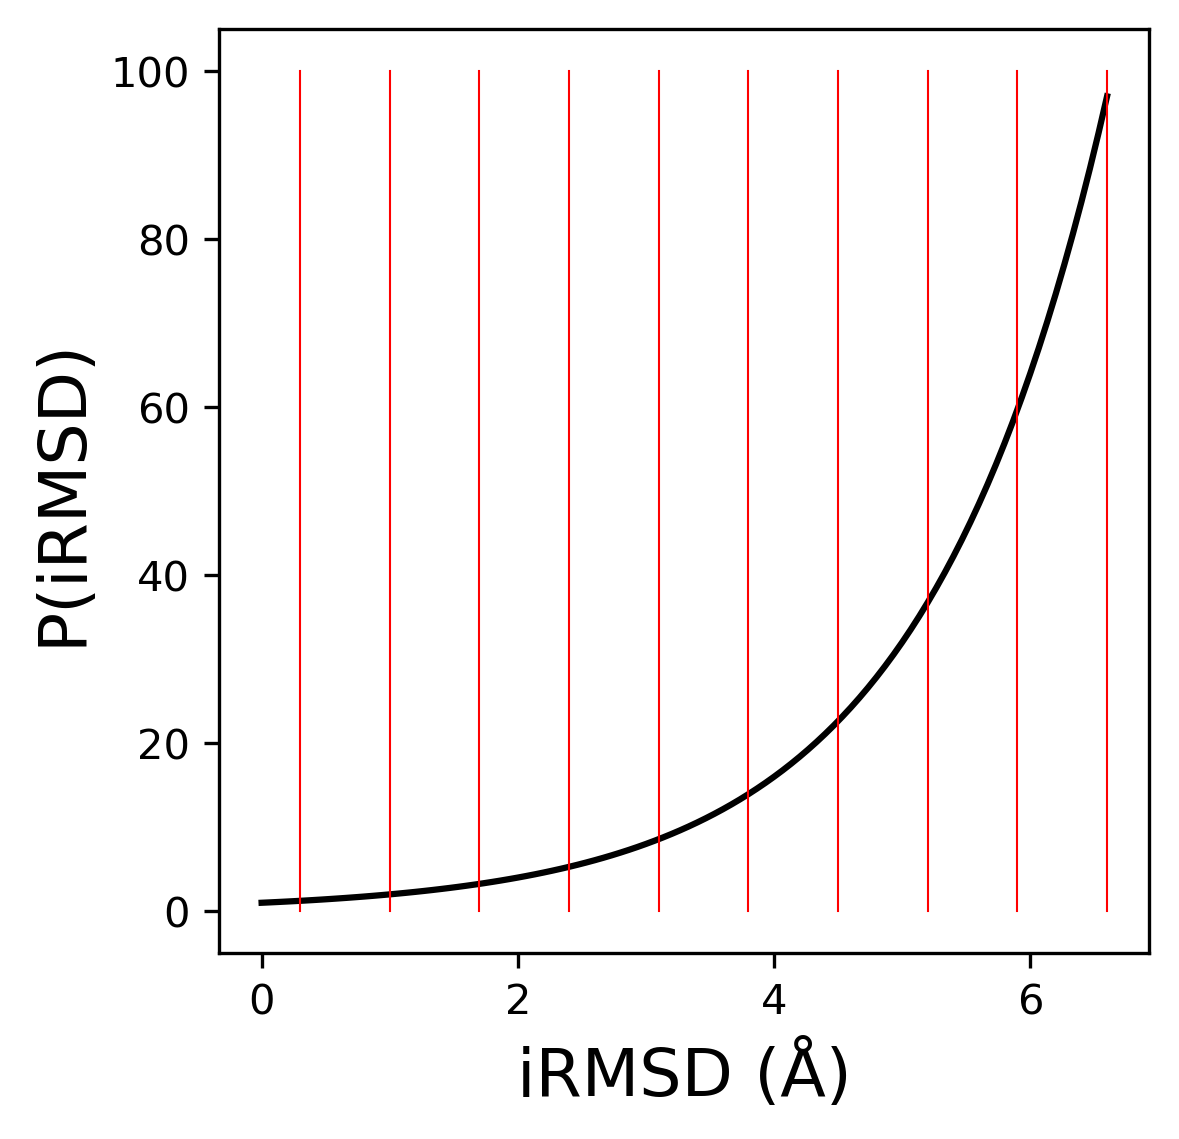

In [68]:
fig, ax = plt.subplots(figsize = (4,4), dpi = 300)

x = np.linspace(0, 6.6, 100)
y = 2**x

ax.plot(x,y, color = "black")

ax.set_xlabel("iRMSD (Å)", fontsize = 16)
ax.set_ylabel("P(iRMSD)", fontsize = 16)

line_space = np.linspace(0.3, 6.6, 10)

for i in range(10):

    ax.plot([line_space[i], line_space[i]], [0, 100], color = "red", linewidth = 0.5)

# ax.set_yscale("log")

# Testing the code on real data

In [10]:
import h5py

In [66]:
def find_interface_edges(edge_reference):
    '''
    Returns the data needed for running the graph
    separability code. 

    Returns the node_indices - simple list of all nodes (np array)
    Returns the node_features (1 for interface node, 0 otherwise)
    Returns the edges in the system (simple [(i,j)...]) edge list
    '''

    node_indices = set([])
    node_features = {} ## where the node index is the key (as a string)
    edges = []

    for (n1, c1, aa1), (n2, c2, aa2) in edge_reference:
        ## node, chain, amino_acid

        ## Cast everything as ints

        n1, n2, c1, c2 = int(n1), int(n2), int(c1), int(c2)

        ## add the edge to the edge_list

        edges.append((n1,n2))

        ## Add the node index to the set

        node_indices.add(n1)
        node_indices.add(n2)

        ## Specify the node features in the dictionary

        if str(n1) not in node_features:
                node_features[str(n1)] = 0
        if str(n2) not in node_features:
            node_features[str(n2)] = 0

        if c1 != c2:
            ## this is an interface node
            if 1 > node_features[str(n1)]:
                node_features[str(n1)] = 1
            if 1 > node_features[str(n2)]:
                node_features[str(n2)] = 1

    ## Condensing the node features into one list

    tmp_features = sorted([(int(k), v) for k,v in node_features.items()])

    node_features = np.array([[v] for k,v in tmp_features])
    
    return np.array(sorted(list(node_indices))), node_features, edges


def get_separability_value(edge_reference):
    '''
    Take the edge reference data structure and 
    calculate the interface and non-interface degree of 
    each node. Then combine at the end in a fraction, which 
    will act as a measure of separability!
    '''

    node_dict = {} ## k: [0,0] where [interface, non-interface] is the degree values

    interface_nodes = set([])

    for (n1, c1, aa1), (n2, c2, aa2) in edge_reference:

        ## If the c1 and c2 are different, then that means they are an interface edge
        ## Keep track of this for each node!

        ## Cast everything as ints

        n1, n2, c1, c2 = int(n1), int(n2), int(c1), int(c2)

        ## Find all the interface nodes

        if c1 != c2:
            interface_nodes.add(n1)
            interface_nodes.add(n2)

    for (n1, c1, aa1), (n2, c2, aa2) in edge_reference:

        n1, n2, c1, c2 = int(n1), int(n2), int(c1), int(c2)

        if n1 in interface_nodes or n2 in interface_nodes:

            ## Strings for simplicity
    
            k1 = str(n1)
            k2 = str(n2)
    
            if k1 not in node_dict:
                node_dict[k1] = [0,0]
            if k2 not in node_dict:
                node_dict[k2] = [0,0]
    
            if c1 != c2:
                ## It is an interface edge
                node_dict[k1][0] += 1
                node_dict[k2][0] += 1
            elif c1 == c2:
                ## It is a homo-edge
    
                node_dict[k1][1] += 1
                node_dict[k2][1] += 1

    ## Filter for only the true interface nodes
    node_dict = {
        k: v for k, v in node_dict.items()
        if v[0] > 0
    }

    ## Get the separability value

    tot_ni_degree = 0 ## Non-interface degree
    tot_i_degree = 0 ## Interface degree

    for k, (i, ni) in node_dict.items():

        tot_ni_degree += ni
        tot_i_degree += 1

    sep_value = tot_i_degree / (tot_ni_degree + tot_i_degree)
    
    return sep_value
            
        

In [69]:
## Checking out the separability metric

os.chdir('/Users/jakesumner/Desktop/Graph_neural_network/graph_structures_hdf5')


with h5py.File(file_name, "r") as f:

    test_edge_reference = np.array(f["complex.7_19_0"]["edge_reference"])  

    test_dict = get_separability_value(test_edge_reference)


In [70]:
test_dict

0.0904836193447738

In [109]:
## Calculate all of the separability values for 1acb

new_sep_dict_1acb = {}

with h5py.File(file_name, "r") as f:

    all_keys = list(f.keys())

    for curr_key in all_keys: 

        try:

            temp_edge_reference = np.array(f[curr_key]["edge_reference"])  
        
            temp_sep_value = get_separability_value(temp_edge_reference)
    
            new_sep_dict_1acb[curr_key] = temp_sep_value

        except:

            print("Failed on", curr_key)

    

Failed on complex.0_3_2
Failed on complex.0_5_45
Failed on complex.15194_1
Failed on complex.18195_0
Failed on complex.25058_5


In [72]:
new_sep_dict_1acb

{'complex.0_0_11': 0.09941520467836257,
 'complex.0_0_12': 0.09711286089238845,
 'complex.0_0_23': 0.09712230215827339,
 'complex.0_0_4': 0.10282776349614396,
 'complex.0_0_47': 0.09864603481624758,
 'complex.0_0_48': 0.0970873786407767,
 'complex.0_10_11': 0.09242144177449169,
 'complex.0_10_28': 0.0900735294117647,
 'complex.0_10_41': 0.09134615384615384,
 'complex.0_10_8': 0.09106529209621993,
 'complex.0_11_28': 0.09276729559748427,
 'complex.0_11_31': 0.09165302782324058,
 'complex.0_11_32': 0.08974358974358974,
 'complex.0_11_33': 0.09482758620689655,
 'complex.0_11_41': 0.09075907590759076,
 'complex.0_11_44': 0.09046052631578948,
 'complex.0_11_5': 0.0920353982300885,
 'complex.0_12_0': 0.09455128205128205,
 'complex.0_12_28': 0.09259259259259259,
 'complex.0_12_30': 0.09185441941074524,
 'complex.0_12_32': 0.08946322067594434,
 'complex.0_12_5': 0.09106529209621993,
 'complex.0_13_18': 0.08787346221441125,
 'complex.0_13_30': 0.0896551724137931,
 'complex.0_13_40': 0.090609555

In [73]:
def create_prob_dist_identical_bins(data, fig, ax, bins = [], n_bins = 100, color = "black", label = None, alpha = 1.0, marker = "o"):
    '''
    plots a probability distribution from the data provided
    '''
    # if bins == []:
    #     bins = np.linspace(min(data),max(data),n_bins)
    #     bin_range = abs(bins[1]-bins[0])
    #     bins = np.array([min(bins)-bin_range] + list(bins) + [max(bins) + bin_range])
    
    n, bins, patches = ax.hist(data, bins=bins, density=True, histtype= "step", alpha = 0)
    bins = np.delete(bins, -1)
    bins += abs(bins[1]-bins[0])/2
    
    
    ax.plot(bins, n, marker=marker, color=color, markerfacecolor='none', label = label, alpha = alpha)
    
    x = np.array(bins)
    y = np.array(n)
    
    return x, y

Text(0, 0.5, 'P($S_G$)')

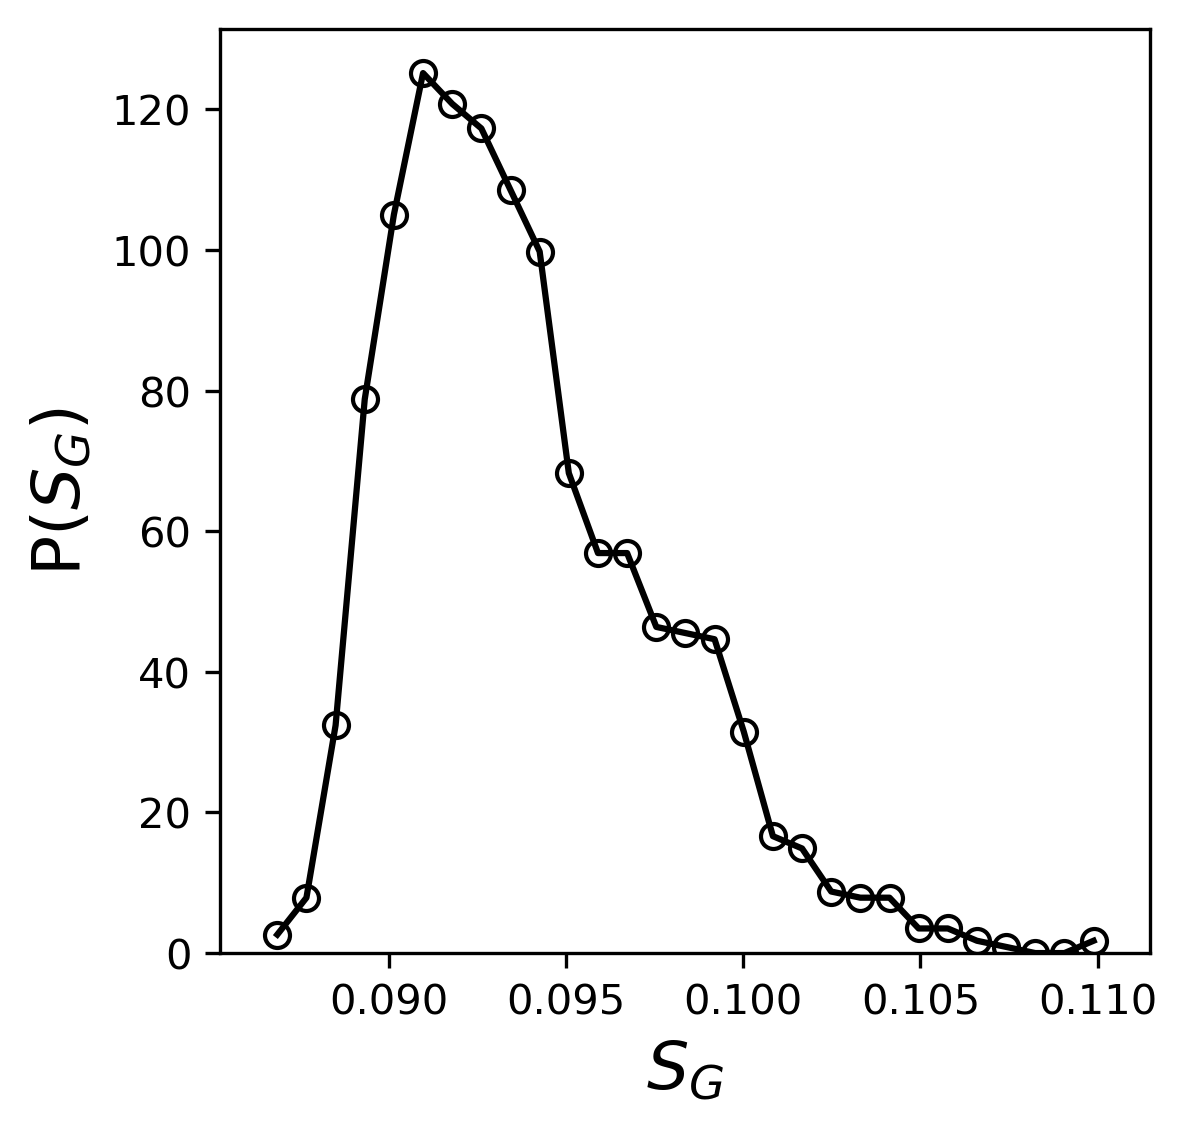

In [74]:
sep_data = list(new_sep_dict_1acb.values())

fig, ax = plt.subplots(figsize = (4,4), dpi = 300)

my_bins = np.linspace(min(sep_data), max(sep_data), 30)

x = create_prob_dist_identical_bins(sep_data, fig, ax, bins = my_bins)

ax.set_xlabel("$S_G$", fontsize = 16)
ax.set_ylabel("P($S_G$)", fontsize = 16)

In [75]:
os.chdir("/Users/jakesumner/Desktop/PPI Project_2/supersampling/scores_high_res_all_residues")

import pandas as pd

sampled_df = pd.read_csv("1acb_sampled_scores.csv")



In [76]:
sampled_df

,Unnamed: 0,Decoy,Model,Fnat,iRMSD,LRMSD,CAPRI,DockQ,IS-Score,ZRank,Rosetta,PyDock,VoroMQA,Dove,Dove_5,Intertwined,Deeprank_gnn_esm
0,0,complex.0_0_11,0,0.000,17.080,55.333,Incorrect,0.010,0.0674,-90.7441,-865.917,-25.407,0.359046,0.3677,0.5775,0.982584,0.323
1,1,complex.0_0_12,0,0.000,13.973,39.901,Incorrect,0.018,0.0674,-53.6282,-869.591,-20.688,0.442720,0.9438,0.4171,0.991843,0.026
2,2,complex.0_0_23,0,0.000,18.394,61.114,Incorrect,0.009,0.0674,-52.9918,-860.852,-16.918,0.353537,0.9591,0.4030,0.993827,0.138
3,3,complex.0_0_47,0,0.000,17.761,53.786,Incorrect,0.010,0.0674,-72.3909,-871.422,-8.684,0.463591,0.8385,0.3918,0.994268,0.018
4,4,complex.0_0_48,0,0.000,8.163,23.286,Incorrect,0.050,0.0674,-72.9910,-885.508,-32.694,0.409047,0.8446,0.5847,0.981702,0.403
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
956,956,complex.9_8_47,9,0.238,2.451,6.731,Acceptable,0.375,0.2457,-78.7915,-878.809,-41.928,0.513004,0.9428,0.5304,0.979497,0.711
957,957,complex.9_8_6,9,0.444,2.013,7.508,Acceptable,0.454,0.3836,-63.5078,-873.010,-35.557,0.521010,0.9545,0.4182,0.986993,0.396
958,958,complex.9_9_15,9,0.444,2.874,6.338,Acceptable,0.434,0.3249,-88.7772,-869.907,-22.375,0.499600,0.9797,0.5444,0.987654,0.297
959,959,complex.9_9_24,9,0.413,2.024,4.443,Medium,0.518,0.3684,-67.2750,-887.365,-33.845,0.428873,0.9802,0.4379,0.979938,0.401


In [77]:
sep_df = pd.DataFrame({"Decoy" : list(new_sep_dict_1acb.keys()), "new_sep" : list(new_sep_dict_1acb.values())})

my_comb_df = sep_df.merge(sampled_df, on = "Decoy")

In [78]:
my_comb_df

,Decoy,new_sep,Unnamed: 0,Model,Fnat,iRMSD,LRMSD,CAPRI,DockQ,IS-Score,ZRank,Rosetta,PyDock,VoroMQA,Dove,Dove_5,Intertwined,Deeprank_gnn_esm
0,complex.0_0_11,0.099415,0,0,0.000,17.080,55.333,Incorrect,0.010,0.0674,-90.7441,-865.917,-25.407,0.359046,0.3677,0.5775,0.982584,0.323
1,complex.0_0_12,0.097113,1,0,0.000,13.973,39.901,Incorrect,0.018,0.0674,-53.6282,-869.591,-20.688,0.442720,0.9438,0.4171,0.991843,0.026
2,complex.0_0_23,0.097122,2,0,0.000,18.394,61.114,Incorrect,0.009,0.0674,-52.9918,-860.852,-16.918,0.353537,0.9591,0.4030,0.993827,0.138
3,complex.0_0_4,0.102828,5,0,0.000,10.591,27.843,Incorrect,0.035,0.0674,-60.5019,-875.982,-18.927,0.375840,0.8932,0.5208,0.991843,0.083
4,complex.0_0_47,0.098646,3,0,0.000,17.761,53.786,Incorrect,0.010,0.0674,-72.3909,-871.422,-8.684,0.463591,0.8385,0.3918,0.994268,0.018
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
954,complex.9_8_47,0.092282,956,9,0.238,2.451,6.731,Acceptable,0.375,0.2457,-78.7915,-878.809,-41.928,0.513004,0.9428,0.5304,0.979497,0.711
955,complex.9_8_6,0.093511,957,9,0.444,2.013,7.508,Acceptable,0.454,0.3836,-63.5078,-873.010,-35.557,0.521010,0.9545,0.4182,0.986993,0.396
956,complex.9_9_15,0.092520,958,9,0.444,2.874,6.338,Acceptable,0.434,0.3249,-88.7772,-869.907,-22.375,0.499600,0.9797,0.5444,0.987654,0.297
957,complex.9_9_24,0.091932,959,9,0.413,2.024,4.443,Medium,0.518,0.3684,-67.2750,-887.365,-33.845,0.428873,0.9802,0.4379,0.979938,0.401


SignificanceResult(statistic=np.float64(-0.6537135708161371), pvalue=np.float64(5.604033223256476e-118))


Text(0, 0.5, 'DockQ')

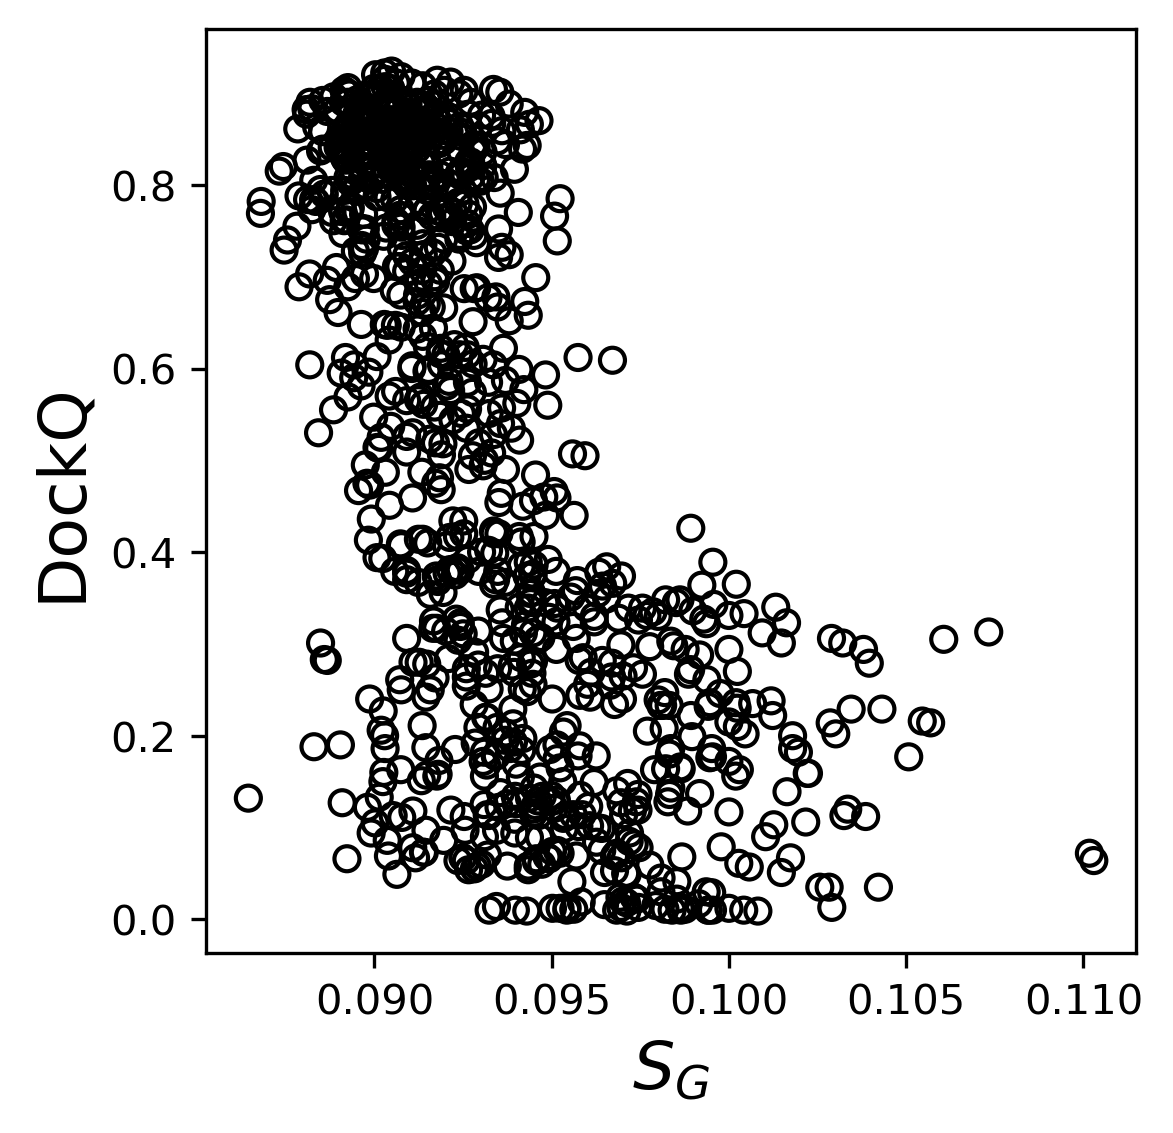

In [80]:
fig, ax = plt.subplots(figsize = (4,4), dpi = 300)

ax.scatter(my_comb_df["new_sep"], my_comb_df["DockQ"], color = "k", facecolor = "None")

print(spearmanr(my_comb_df["new_sep"], my_comb_df["DockQ"]))


ax.set_xlabel("$S_G$", fontsize = 16)
ax.set_ylabel("DockQ", fontsize = 16)

SignificanceResult(statistic=np.float64(-0.5277655069224161), pvalue=np.float64(6.972007469706317e-70))


Text(0, 0.5, 'DockQ')

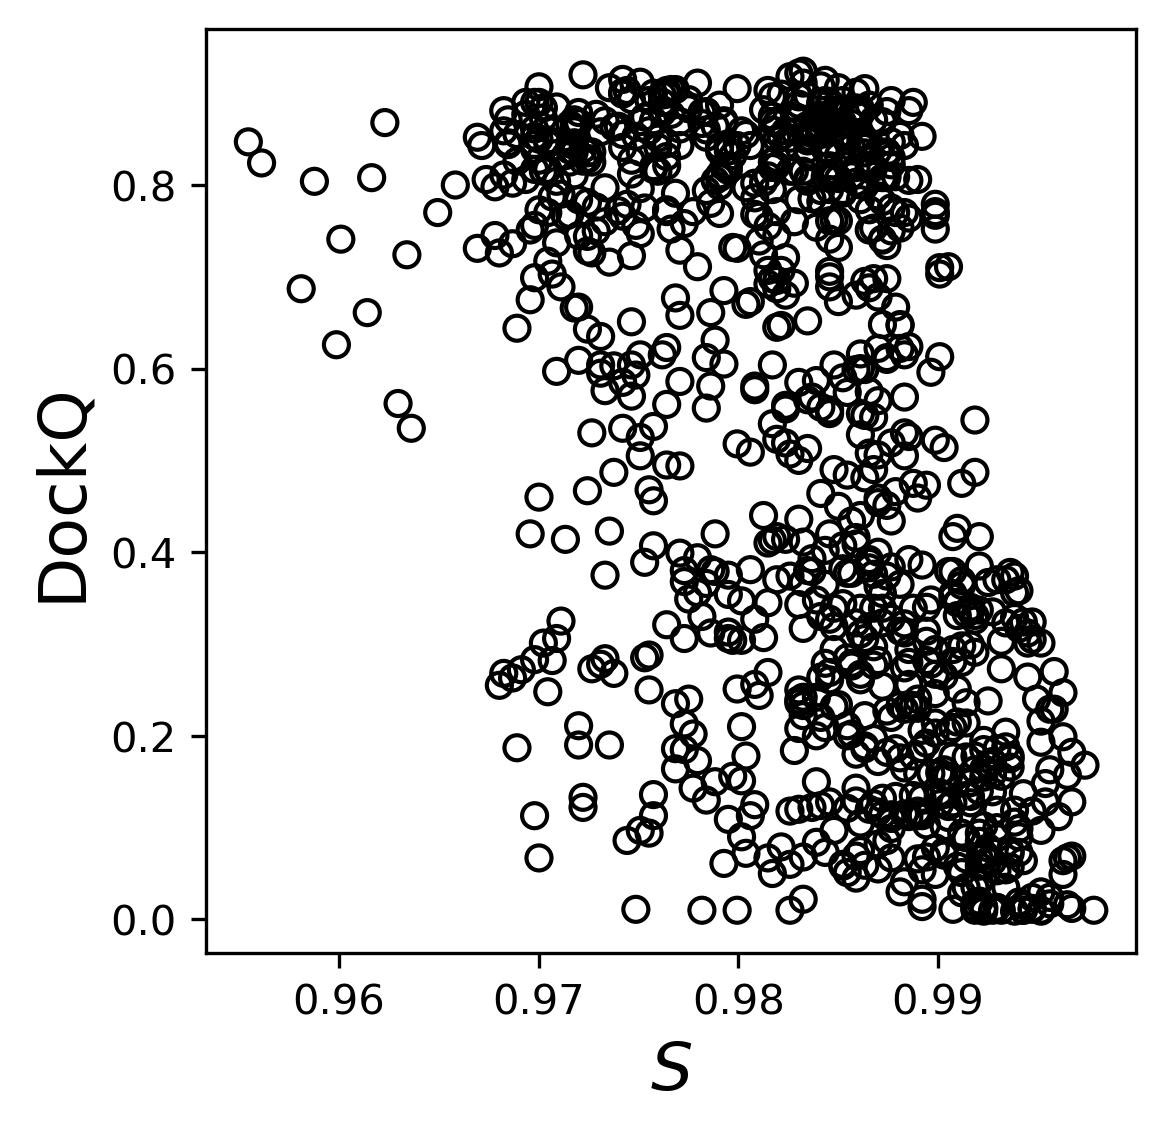

In [81]:
fig, ax = plt.subplots(figsize = (4,4), dpi = 300)

ax.scatter(my_comb_df["Intertwined"], my_comb_df["DockQ"], color = "k", facecolor = "None")

print(spearmanr(my_comb_df["Intertwined"], my_comb_df["DockQ"]))

ax.set_xlabel("$S$", fontsize = 16)
ax.set_ylabel("DockQ", fontsize = 16)

In [82]:
from scipy.stats import pearsonr, spearmanr

PearsonRResult(statistic=np.float64(0.4098786911944194), pvalue=np.float64(3.761639042314908e-40))
SignificanceResult(statistic=np.float64(0.413153103646611), pvalue=np.float64(7.902223887810177e-41))


Text(0, 0.5, 'S')

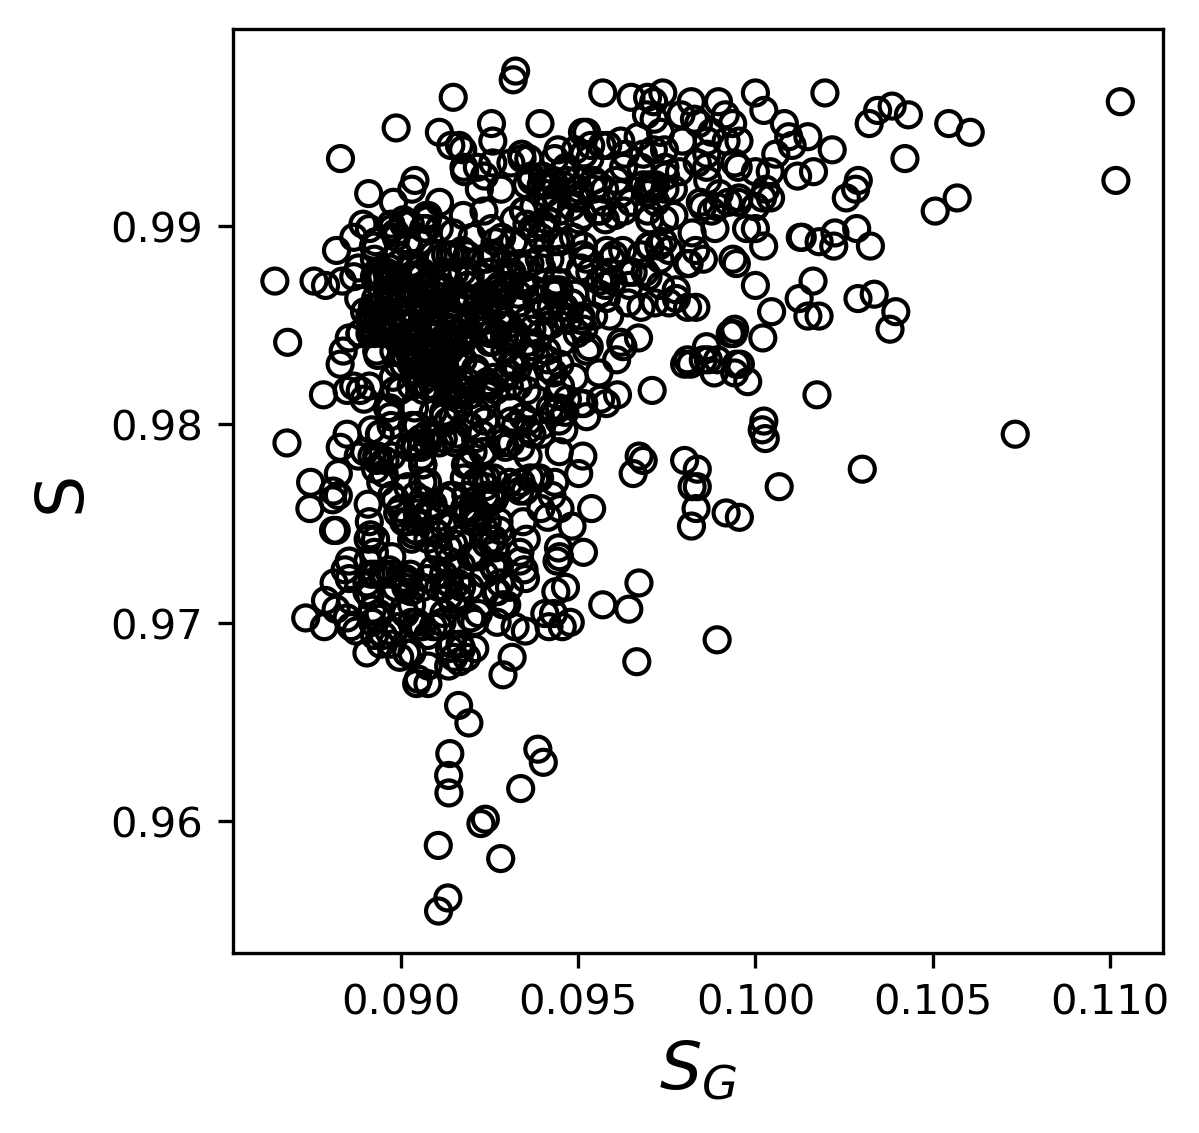

In [84]:
fig, ax = plt.subplots(figsize = (4,4), dpi = 300)

ax.scatter(my_comb_df["new_sep"], my_comb_df["Intertwined"], color = "k", facecolor = "None")

print(pearsonr(my_comb_df["new_sep"], my_comb_df["Intertwined"]))
print(spearmanr(my_comb_df["new_sep"], my_comb_df["Intertwined"]))

ax.set_xlabel("$S_G$", fontsize = 16)
ax.set_ylabel("S", fontsize = 16)

In [36]:
## Loading in the data from 1acb

os.chdir('/Users/jakesumner/Desktop/Graph_neural_network/graph_structures_hdf5')

file_name = "1acb.hdf5"

with h5py.File(file_name, "r") as f:

    # print(f.keys())

    for val in list(f.keys()):
        if "_0_" in val:
            print(val)
    print(np.array(f["complex.7_19_0"]["edge_reference"]))

    test_edge_reference = np.array(f["complex.7_19_0"]["edge_reference"])

    test_indices, test_features, test_edges = find_interface_edges(test_edge_reference)

    # print(test_indices)
    # print(test_features)
    # print(test_edges)

    ## now a bad model

    bad_edge_reference = np.array(f["complex.1_0_46"]["edge_reference"])

    bad_indices, bad_features, bad_edges = find_interface_edges(bad_edge_reference)

complex.0_0_11
complex.0_0_12
complex.0_0_23
complex.0_0_4
complex.0_0_47
complex.0_0_48
complex.1_0_1
complex.1_0_15
complex.1_0_3
complex.1_0_46
complex.2_0_18
complex.2_0_26
complex.2_0_34
complex.2_0_5
complex.2_0_7
complex.3_0_10
complex.3_0_36
complex.3_0_39
complex.3_0_42
complex.3_0_43
complex.3_0_45
complex.4_0_13
complex.4_0_28
complex.5_0_0
complex.5_0_2
complex.5_0_22
complex.5_0_24
complex.5_0_29
complex.5_0_30
complex.5_0_32
complex.5_0_37
complex.5_0_38
complex.5_0_6
complex.5_0_9
complex.6_0_14
complex.6_0_19
complex.6_0_20
complex.6_0_25
complex.6_0_35
complex.6_0_49
complex.6_0_8
complex.7_0_16
complex.7_0_17
complex.7_0_31
complex.7_0_33
complex.7_0_44
complex.8_0_27
complex.8_0_41
complex.9_0_21
complex.9_0_40
[[[b'0' b'0' b'CYS']
  [b'1' b'0' b'GLY']]

 [[b'0' b'0' b'CYS']
  [b'2' b'0' b'VAL']]

 [[b'0' b'0' b'CYS']
  [b'44' b'0' b'ILE']]

 ...

 [[b'301' b'1' b'HIS']
  [b'302' b'1' b'VAL']]

 [[b'301' b'1' b'HIS']
  [b'303' b'1' b'GLY']]

 [[b'302' b'1' b'VAL']
  

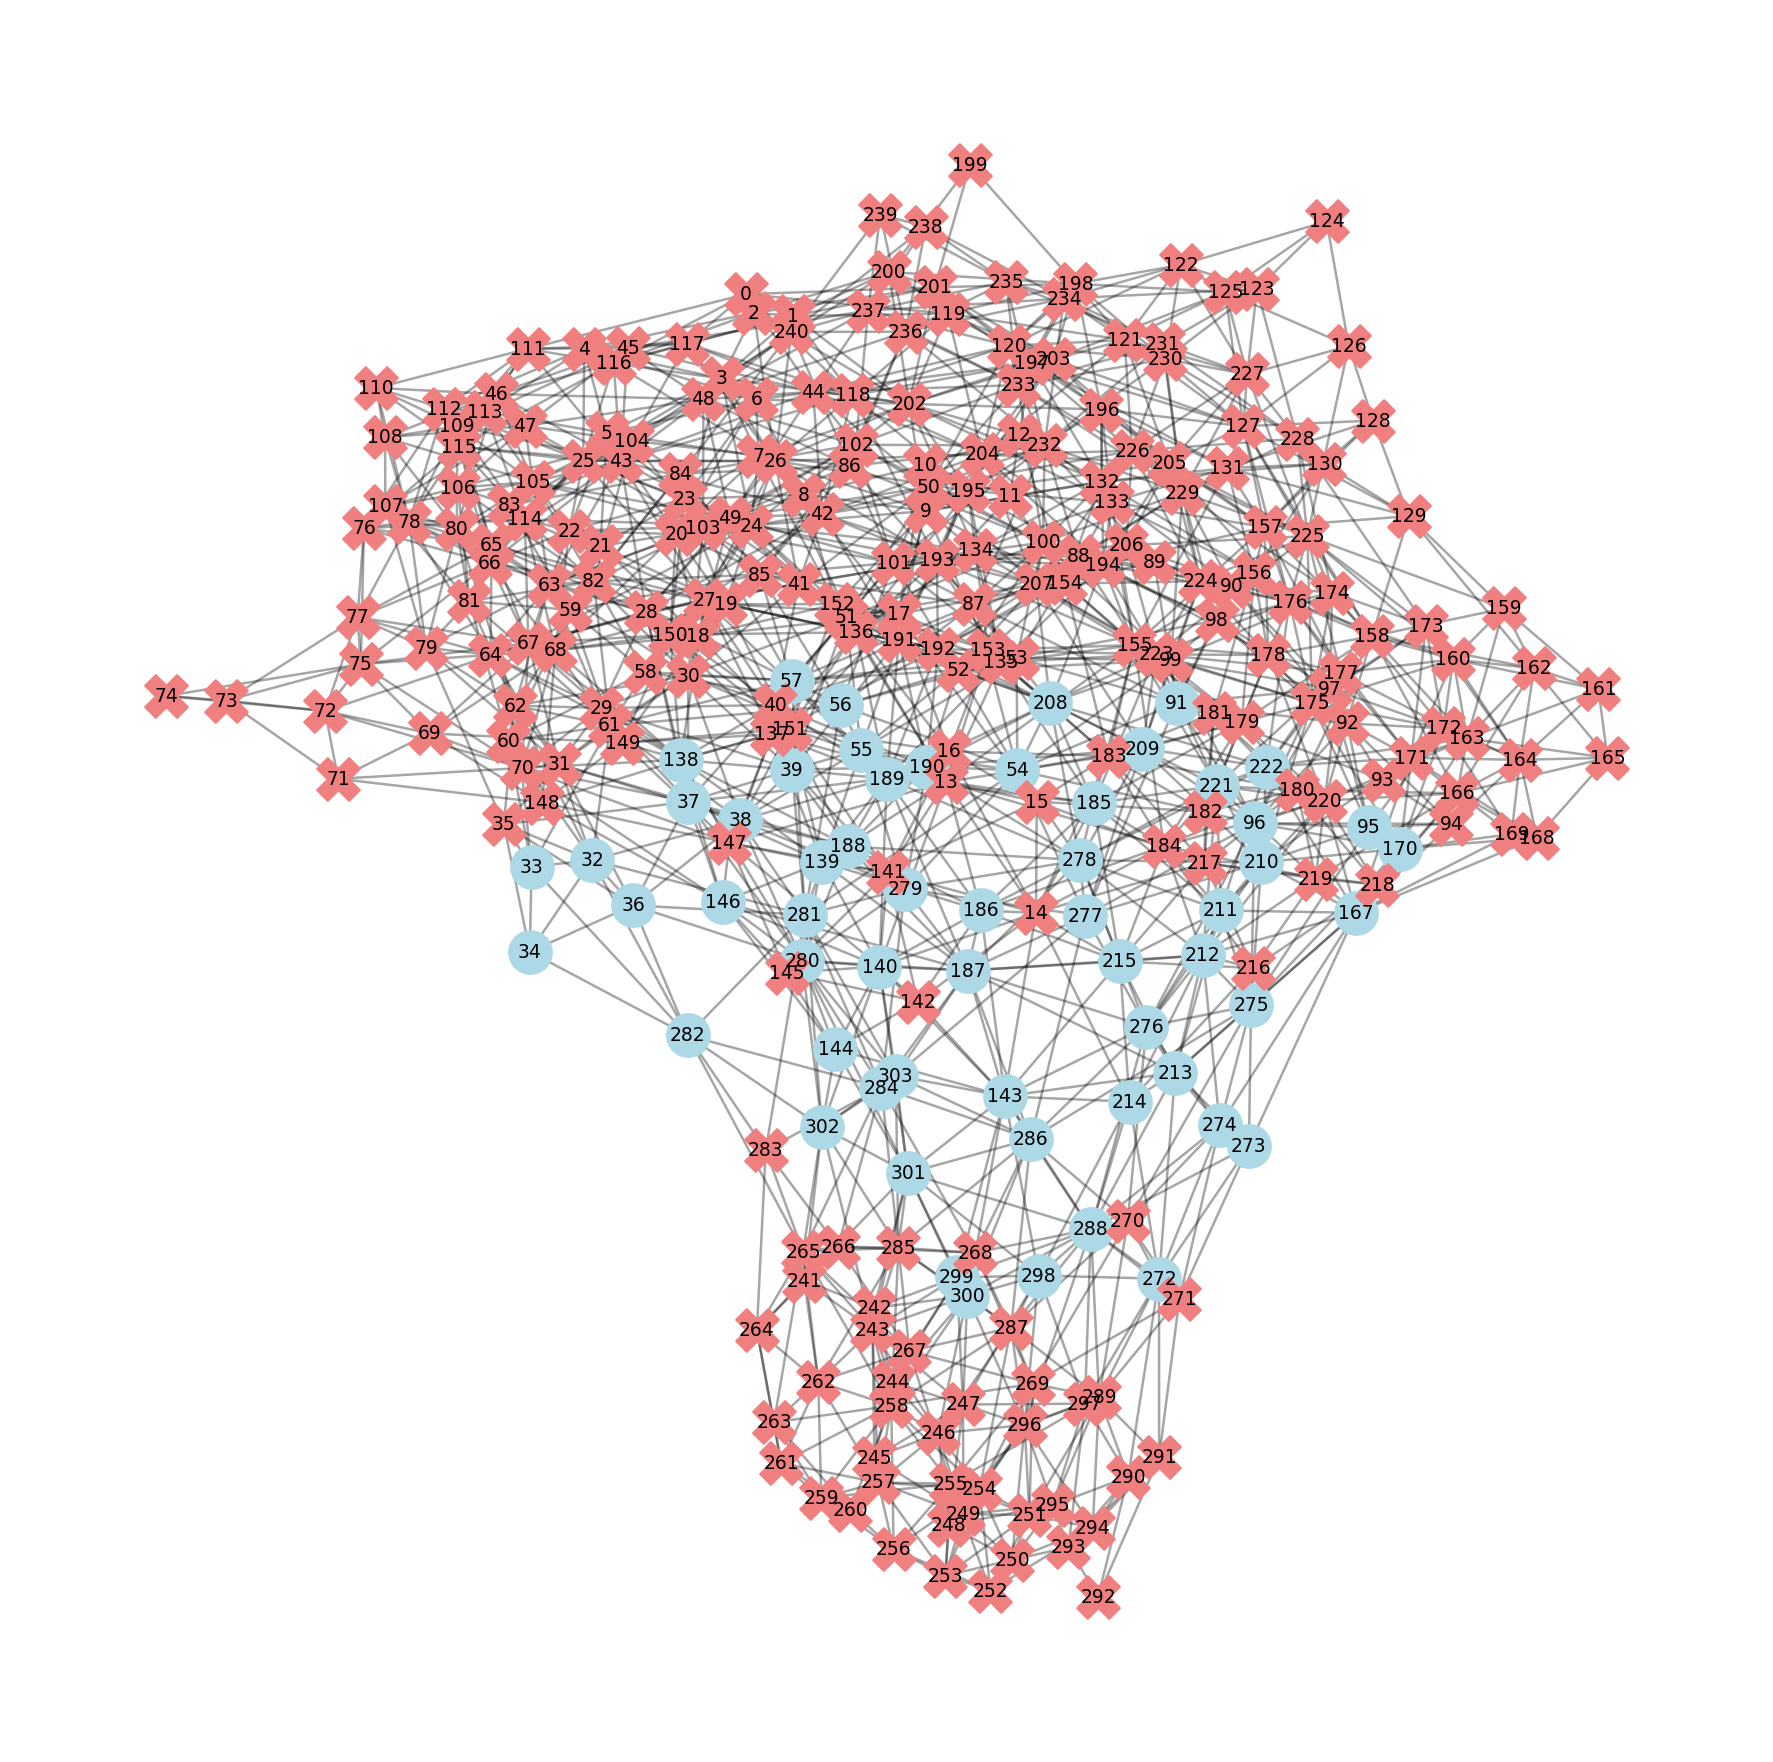

In [21]:
## Visualize the graph model - near native

G = build_graph(test_indices, test_features, test_edges, pos_id=0)

draw_graph_with_path(
    G,
    seed=1,
    show_blocked=True
)

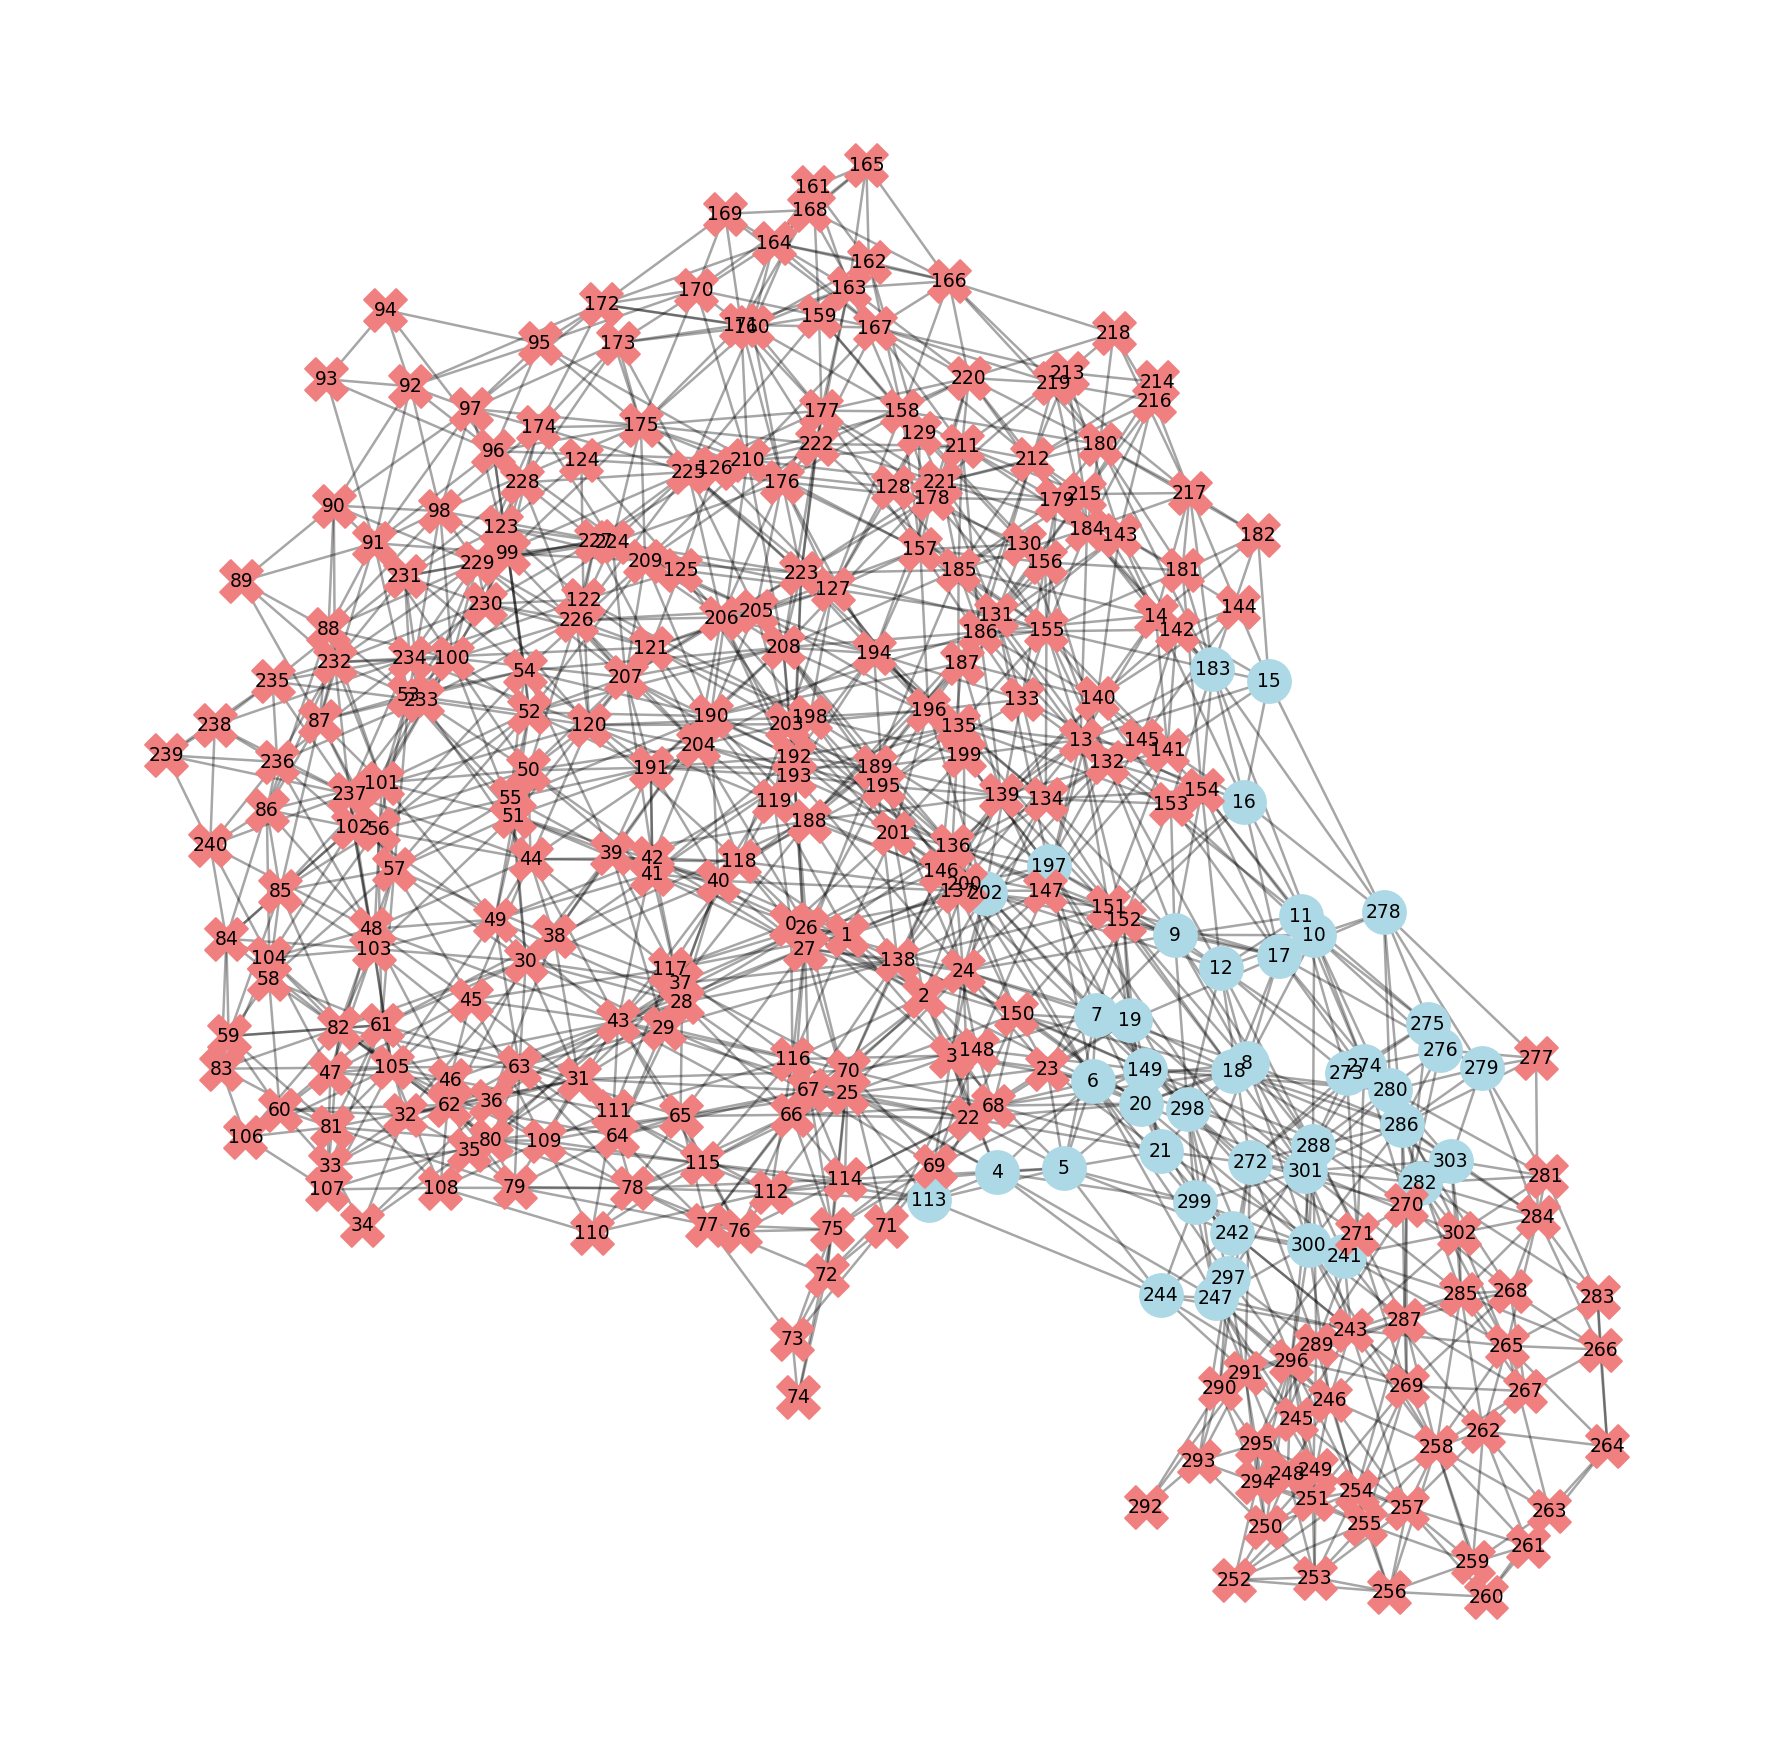

In [17]:
## Visualize the graph model - near native

G = build_graph(bad_indices, bad_features, bad_edges, pos_id=0)

draw_graph_with_path(
    G,
    seed=3,
    show_blocked=True
)

In [90]:
## Another one

## Checking out the separability metric

os.chdir('/Users/jakesumner/Desktop/Graph_neural_network/graph_structures_hdf5')

file_name = "1ay7.hdf5"


In [93]:
## Calculate all of the separability values for 1acb

new_sep_dict_1ay7 = {}

with h5py.File(file_name, "r") as f:

    all_keys = list(f.keys())

    for curr_key in all_keys: 

        try:

            temp_edge_reference = np.array(f[curr_key]["edge_reference"])  
        
            temp_sep_value = get_separability_value(temp_edge_reference)
    
            new_sep_dict_1ay7[curr_key] = temp_sep_value

        except:

            print("Failed on", curr_key)

    

Failed on complex.22285_5
Failed on complex.27188_0
Failed on complex.4_0_13
Failed on complex.5_0_27
Failed on complex.9_9_11


In [94]:
os.chdir("/Users/jakesumner/Desktop/PPI Project_2/supersampling/scores_high_res_all_residues")

import pandas as pd

sampled_df = pd.read_csv("1ay7_sampled_scores.csv")

sep_df = pd.DataFrame({"Decoy" : list(new_sep_dict_1ay7.keys()), "new_sep" : list(new_sep_dict_1ay7.values())})

my_comb_df = sep_df.merge(sampled_df, on = "Decoy")

In [95]:
my_comb_df

,Decoy,new_sep,Unnamed: 0,Model,Fnat,iRMSD,LRMSD,CAPRI,DockQ,IS-Score,ZRank,Rosetta,PyDock,VoroMQA,Dove,Dove_5,Intertwined,Deeprank_gnn_esm
0,complex.0_0_2,0.102828,1,0,0.000,9.188,36.842,Incorrect,0.026,0.0636,-47.4250,-521.068,-19.779,0.485730,0.8924,0.3583,0.987130,0.011
1,complex.0_0_29,0.105572,0,0,0.000,13.547,55.214,Incorrect,0.012,0.0636,-52.7136,-509.086,-16.051,0.382181,0.9436,0.4403,0.989565,0.075
2,complex.0_0_3,0.098901,5,0,0.000,13.298,51.294,Incorrect,0.013,0.0636,-28.4197,-517.185,-9.625,0.466670,0.9781,0.2947,0.994087,0.003
3,complex.0_0_32,0.103175,2,0,0.025,12.612,33.477,Incorrect,0.033,0.0636,-46.3331,-523.791,-4.774,0.220355,0.7747,0.3465,0.996870,0.018
4,complex.0_0_35,0.099688,3,0,0.000,9.578,41.922,Incorrect,0.021,0.0636,-46.8489,-534.531,-9.514,0.265245,0.9358,0.3905,0.993391,0.005
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
947,complex.9_8_29,0.099462,949,9,0.425,2.240,9.143,Acceptable,0.399,0.2597,-63.8393,-528.261,-23.967,0.372662,0.7765,0.3871,0.989217,-0.001
948,complex.9_8_44,0.096535,950,9,0.350,3.008,10.714,Acceptable,0.312,0.2223,-56.7117,-528.817,-29.069,0.354795,0.9059,0.3702,0.987826,-0.000
949,complex.9_9_1,0.095477,954,9,0.550,2.661,8.986,Acceptable,0.421,0.3278,-64.4593,-518.403,-27.241,0.419049,0.9010,0.5161,0.991652,-0.004
950,complex.9_9_13,0.100796,952,9,0.500,2.704,7.519,Acceptable,0.432,0.3017,-55.9399,-512.452,-14.843,0.397189,0.7980,0.4774,0.987826,0.022


PearsonRResult(statistic=np.float64(0.07637404015928194), pvalue=np.float64(0.01843170099843125))
SignificanceResult(statistic=np.float64(-0.03238527169258125), pvalue=np.float64(0.31819194010263013))


Text(0, 0.5, 'S')

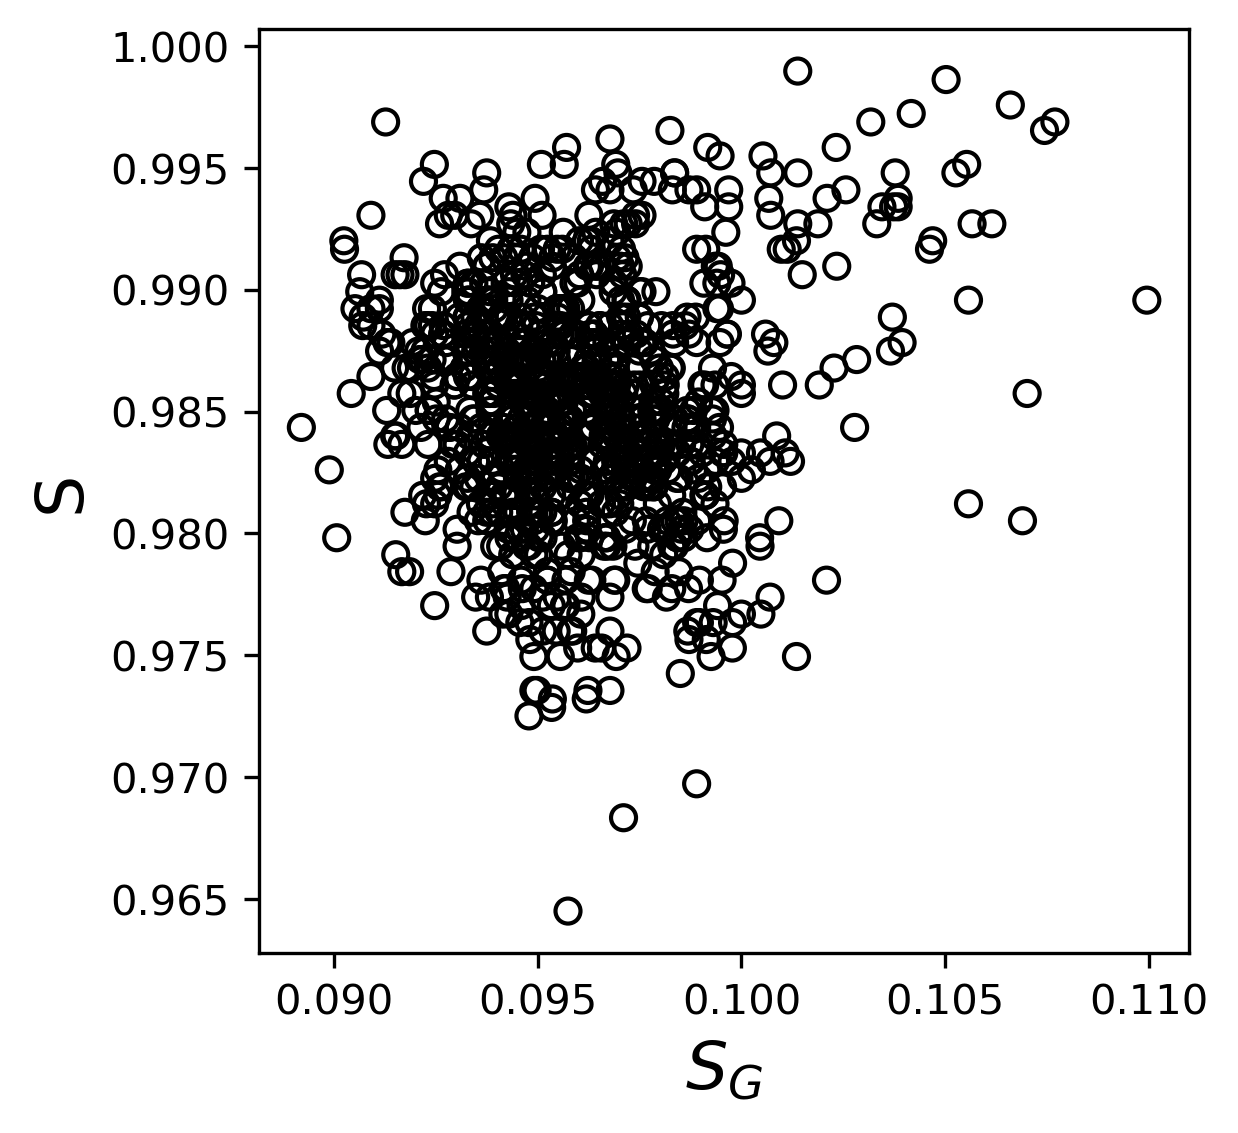

In [96]:
fig, ax = plt.subplots(figsize = (4,4), dpi = 300)

ax.scatter(my_comb_df["new_sep"], my_comb_df["Intertwined"], color = "k", facecolor = "None")

print(pearsonr(my_comb_df["new_sep"], my_comb_df["Intertwined"]))
print(spearmanr(my_comb_df["new_sep"], my_comb_df["Intertwined"]))

ax.set_xlabel("$S_G$", fontsize = 16)
ax.set_ylabel("S", fontsize = 16)

SignificanceResult(statistic=np.float64(-0.23762600540487822), pvalue=np.float64(1.0953871372649596e-13))


Text(0, 0.5, 'DockQ')

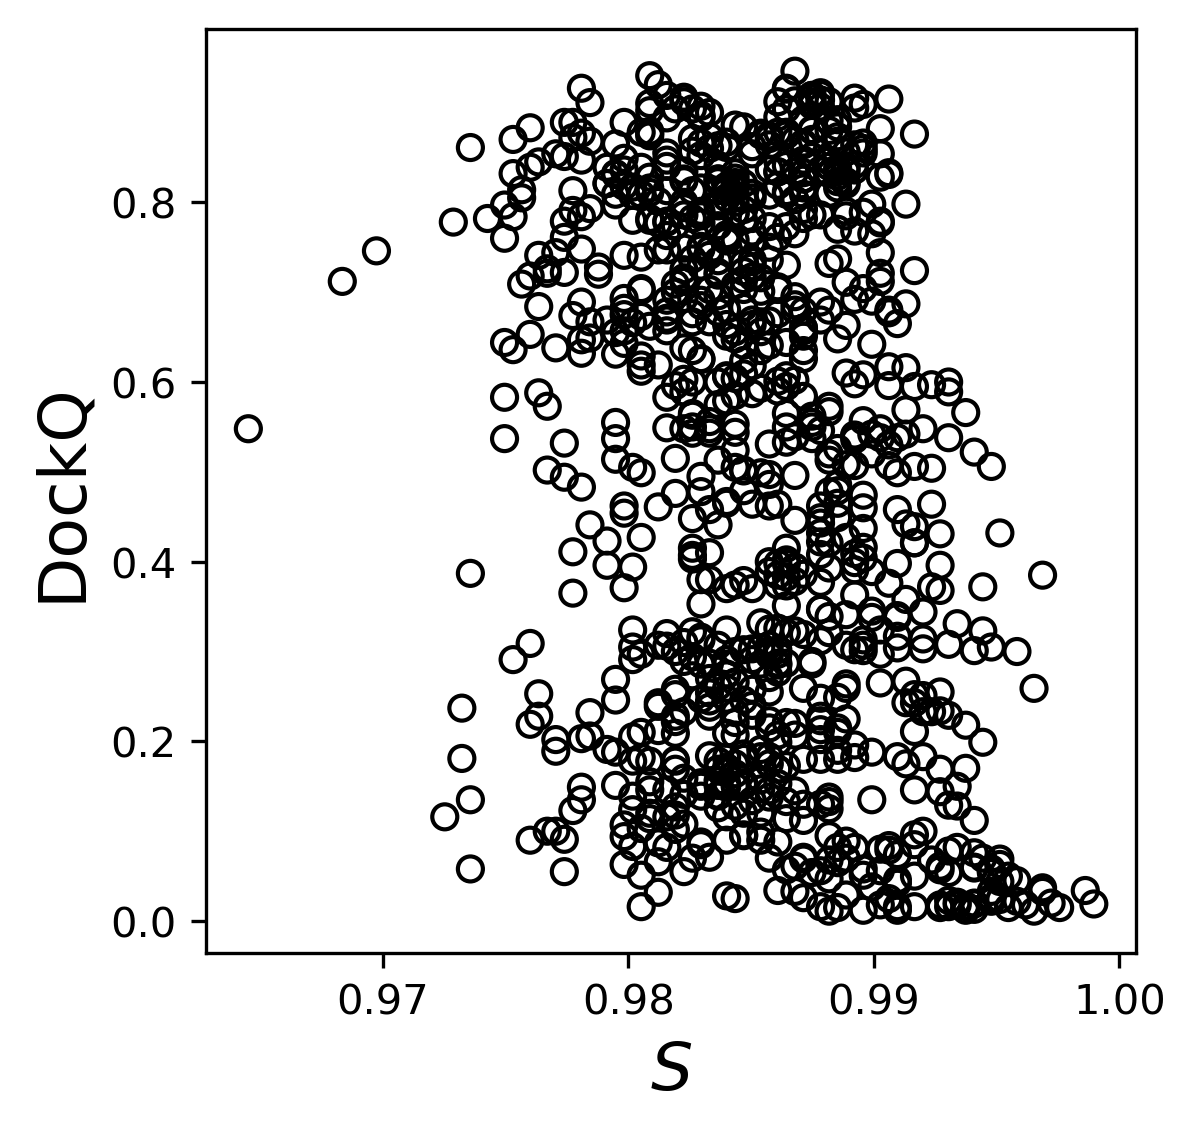

In [97]:
fig, ax = plt.subplots(figsize = (4,4), dpi = 300)

ax.scatter(my_comb_df["Intertwined"], my_comb_df["DockQ"], color = "k", facecolor = "None")

print(spearmanr(my_comb_df["Intertwined"], my_comb_df["DockQ"]))

ax.set_xlabel("$S$", fontsize = 16)
ax.set_ylabel("DockQ", fontsize = 16)

SignificanceResult(statistic=np.float64(-0.36781810217783906), pvalue=np.float64(7.209477455346421e-32))


Text(0, 0.5, 'DockQ')

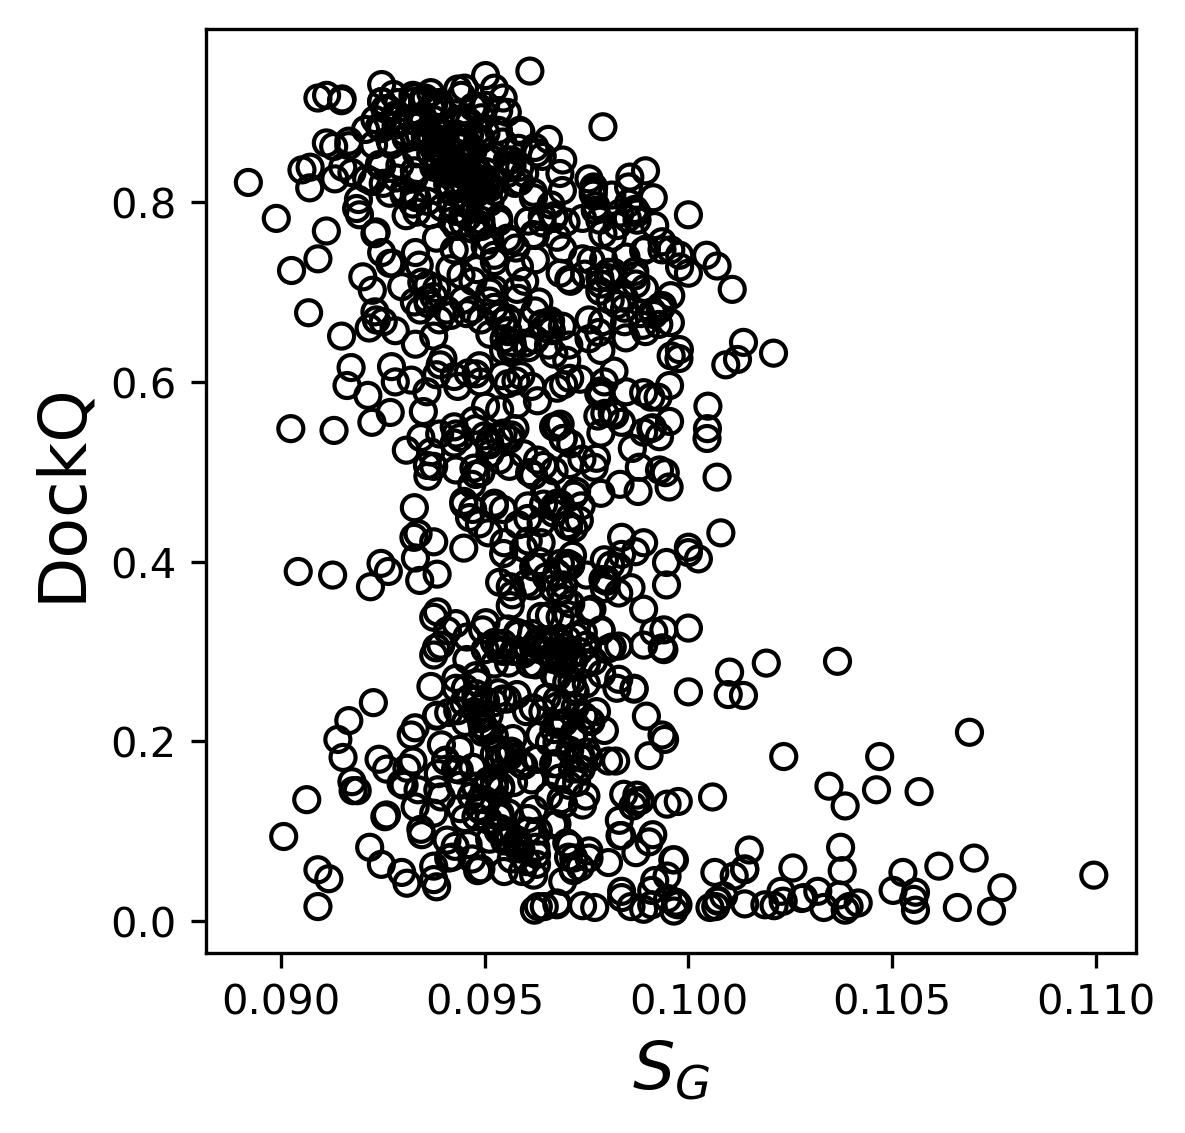

In [98]:
fig, ax = plt.subplots(figsize = (4,4), dpi = 300)

ax.scatter(my_comb_df["new_sep"], my_comb_df["DockQ"], color = "k", facecolor = "None")

print(spearmanr(my_comb_df["new_sep"], my_comb_df["DockQ"]))


ax.set_xlabel("$S_G$", fontsize = 16)
ax.set_ylabel("DockQ", fontsize = 16)

## Testing the new version of the $S_G$ calculation

In [107]:
def get_separability_value_alt(edge_reference):
    '''
    Take the edge reference data structure and 
    calculate the interface and non-interface degree of 
    each node. Then combine at the end in a fraction, which 
    will act as a measure of separability!
    '''

    node_dict = {} ## k: [0,0] where [interface, non-interface] is the degree values

    interface_nodes = set([])

    for (n1, c1, aa1), (n2, c2, aa2) in edge_reference:

        ## If the c1 and c2 are different, then that means they are an interface edge
        ## Keep track of this for each node!

        ## Cast everything as ints

        n1, n2, c1, c2 = int(n1), int(n2), int(c1), int(c2)import matplotlib as mpl
import matplotlib.pyplot as plt

mpl.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.serif": ["Computer Modern Roman"],
    "axes.labelsize": 12,
    "font.size": 12,
    "legend.fontsize": 10,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "text.latex.preamble": r"\usepackage{amsmath}",
})


        ## Find all the interface nodes

        if c1 != c2:
            interface_nodes.add(n1)
            interface_nodes.add(n2)

    for (n1, c1, aa1), (n2, c2, aa2) in edge_reference:

        n1, n2, c1, c2 = int(n1), int(n2), int(c1), int(c2)

        if n1 in interface_nodes or n2 in interface_nodes:

            ## Strings for simplicity
    
            k1 = str(n1)
            k2 = str(n2)
    
            if k1 not in node_dict:
                node_dict[k1] = [0,0]
            if k2 not in node_dict:
                node_dict[k2] = [0,0]
    
            if c1 != c2:
                ## It is an interface edge
                node_dict[k1][0] += 1
                node_dict[k2][0] += 1
            elif c1 == c2:
                ## It is a homo-edge
    
                node_dict[k1][1] += 1
                node_dict[k2][1] += 1

    ## Filter for only the true interface nodes
    node_dict = {
        k: v for k, v in node_dict.items()
        if v[0] > 0
    }

    ## Get the separability value

    sep_values = []

    for k, (v1, v2) in node_dict.items():

        sep_values.append(v1/(v1 + v2))
    
    return np.mean(sep_values)

In [108]:
## Calculate all of the separability values for 1acb

os.chdir('/Users/jakesumner/Desktop/Graph_neural_network/graph_structures_hdf5')

file_name = "1acb.hdf5"

alt_sep_dict_1acb = {}

with h5py.File(file_name, "r") as f:

    all_keys = list(f.keys())

    for curr_key in all_keys: 

        try:

            temp_edge_reference = np.array(f[curr_key]["edge_reference"])  
        
            temp_sep_value = get_separability_value_alt(temp_edge_reference)
    
            alt_sep_dict_1acb[curr_key] = temp_sep_value

        except:

            print("Failed on", curr_key)

    

Failed on complex.0_3_2
Failed on complex.0_5_45
Failed on complex.15194_1
Failed on complex.18195_0
Failed on complex.25058_5


In [112]:
os.chdir("/Users/jakesumner/Desktop/PPI Project_2/supersampling/scores_high_res_all_residues")

sampled_df_1acb = pd.read_csv("1acb_sampled_scores.csv")

sep_df = pd.DataFrame({"Decoy" : list(alt_sep_dict_1acb.keys()), "new_sep" : list(new_sep_dict_1acb.values()), "alt_sep" : list(alt_sep_dict_1acb.values())})

my_comb_df_1acb = sep_df.merge(sampled_df_1acb, on = "Decoy")

In [113]:
my_comb_df_1acb

,Decoy,new_sep,alt_sep,Unnamed: 0,Model,Fnat,iRMSD,LRMSD,CAPRI,DockQ,IS-Score,ZRank,Rosetta,PyDock,VoroMQA,Dove,Dove_5,Intertwined,Deeprank_gnn_esm
0,complex.0_0_11,0.099415,0.256803,0,0,0.000,17.080,55.333,Incorrect,0.010,0.0674,-90.7441,-865.917,-25.407,0.359046,0.3677,0.5775,0.982584,0.323
1,complex.0_0_12,0.097113,0.254905,1,0,0.000,13.973,39.901,Incorrect,0.018,0.0674,-53.6282,-869.591,-20.688,0.442720,0.9438,0.4171,0.991843,0.026
2,complex.0_0_23,0.097122,0.215022,2,0,0.000,18.394,61.114,Incorrect,0.009,0.0674,-52.9918,-860.852,-16.918,0.353537,0.9591,0.4030,0.993827,0.138
3,complex.0_0_4,0.102828,0.263086,5,0,0.000,10.591,27.843,Incorrect,0.035,0.0674,-60.5019,-875.982,-18.927,0.375840,0.8932,0.5208,0.991843,0.083
4,complex.0_0_47,0.098646,0.256212,3,0,0.000,17.761,53.786,Incorrect,0.010,0.0674,-72.3909,-871.422,-8.684,0.463591,0.8385,0.3918,0.994268,0.018
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
954,complex.9_8_47,0.092282,0.233405,956,9,0.238,2.451,6.731,Acceptable,0.375,0.2457,-78.7915,-878.809,-41.928,0.513004,0.9428,0.5304,0.979497,0.711
955,complex.9_8_6,0.093511,0.243728,957,9,0.444,2.013,7.508,Acceptable,0.454,0.3836,-63.5078,-873.010,-35.557,0.521010,0.9545,0.4182,0.986993,0.396
956,complex.9_9_15,0.092520,0.227965,958,9,0.444,2.874,6.338,Acceptable,0.434,0.3249,-88.7772,-869.907,-22.375,0.499600,0.9797,0.5444,0.987654,0.297
957,complex.9_9_24,0.091932,0.235635,959,9,0.413,2.024,4.443,Medium,0.518,0.3684,-67.2750,-887.365,-33.845,0.428873,0.9802,0.4379,0.979938,0.401


In [ ]:
fig, ax = plt.subplots(figsize = (4,4), dpi = 300)

ax.scatter(my_comb_df_1acb["new_sep"], my_comb_df_1acb["Intertwined"], color = "k", facecolor = "None")

print(pearsonr(my_comb_df_1acb["new_sep"], my_comb_df_1acb["Intertwined"]))
print(spearmanr(my_comb_df_1acb["new_sep"], my_comb_df_1acb["Intertwined"]))

ax.set_xlabel("$S_G$", fontsize = 16)
ax.set_ylabel("S", fontsize = 16)